<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://professor.uvv.br/Content/img/logo-uvv.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>DATA SCIENCE PROJECT</b></CENTER><br/>
        <CENTER><b>WORKFLOW PARTE 2 DO PROJETO</b></CENTER><br/>

NOME COMPLETO: DAVI VAGO SOARES

LINK PARA SEU PRÓPRIO COLAB: [davi_vago_soares_WORKFLOW - PARTE 2.ipynb](https://colab.research.google.com/drive/1wZNzVEpLJ8_5adpDURn0rJnbdDmqgVxE?usp=sharing)

LINK PARA SEU GITHUB: [Aqui](https://github.com/Davi-Vago/uvv-wine)

**LINK PARA SEU PRÓPRIO VÍDEO NO YOUTUBE - OBRIGATÓRIO:** [Aqui](https://www.youtube.com/watch?v=K4O4XQyMX4A)

# **Cenário Fictício**:

Prezados(as) alunos(as),

É ótimo que você como **Consultor** ( ***Data Science Consultant*** ) do **Projeto Data Science** tenha chegado no **Workflow - Parte 2: Aprendizado de Máquina** (*Machine Learnning*). A *Incrível Biblioteca*:

<center>

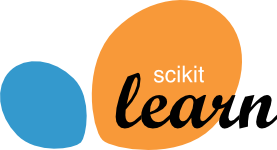

<center>

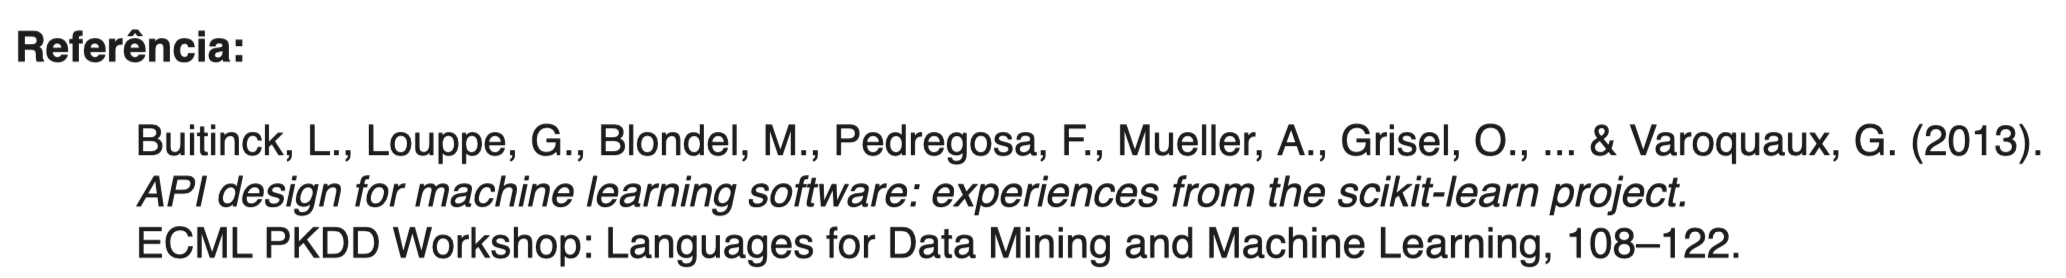

Neste etapa, você irá usar conjuntos (vários) que virão do **Workflow - Parte1**, a saber:

*   Conjunto de Treinamento: ***train***
*   Conjunto de Validação: ***validation***
*   Conjunto de Teste: ***test***

<center>

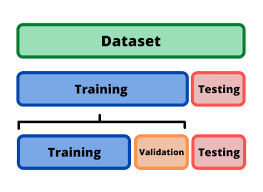

Ou seja:

<center>

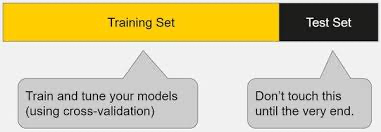


Com todas as Análises e *Insights* (**Estatistica Descritiva,** **Testes de Hipóteses** e os **Métodos Quantitativos**) que irão garatir que temos conjuntos com Qualidade (***Best Quality Analytics***) e que são ótimas amostras em relação a população ratificando justamente a importância da Parte 1 do projeto.

<center>

**EXCELENTE!!! Agora podemos ir mais longe no Universo Python!** 🚀🚀🚀

</center>

Podemos praticar as técnicas mais avançadas do **Aprendizado de Máquina** (*Machine Learnning*) e criarmos aprendizes dos seguintes modelos, a saber:

*   REGRESSOR: Modelo de Regressão: [Regression](https://scikit-learn.org/stable/supervised_learning.html)
*   CLUSTERIZADOR: Modelo de Agrupamento: [Clustering](https://scikit-learn.org/stable/modules/clustering.html)
*   CLASSIFICADOR: Modelo de Classificação:  [Classification](https://scikit-learn.org/stable/supervised_learning.html)

Para garantir organização, profundidade técnica e coerência metodológica no desenvolvimento do projeto, adotaremos um **Fluxo de Projeto (Ciclo de Vida)** composto pela atividades estabelecidas no **Workflow - Parte 2**, conforme a seguir:

# BIBLIOTECAS E FUNÇÕES E CÓDIGOS

## Bibliotecas

In [1]:

# Manipulação de Dados

import gc
import numpy as np
import pandas as pd


# Visualização

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from IPython.display import Image
from pandas.plotting import parallel_coordinates

%matplotlib inline


# Métricas e Avaliação

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    confusion_matrix
)

from sklearn import metrics


# Pré-processamento

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)


# Utilidades e Validação

from sklearn.base import clone
from sklearn.utils import shuffle
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)


# Regressão

from sklearn import linear_model
from sklearn.linear_model import (
    LinearRegression
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from sklearn.compose import TransformedTargetRegressor


# Classificação

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.naive_bayes import GaussianNB

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import (
    SVC,
    LinearSVC
)

from sklearn.linear_model import LogisticRegression

from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from sklearn.neural_network import MLPClassifier


# Clustering

from sklearn.cluster import (
    KMeans,
    AffinityPropagation,
    AgglomerativeClustering
)

from scipy.spatial.distance import cdist


# Outros

from sklearn import svm

## Load dos Datasets:

In [ ]:
train = pd.read_csv('/content/uwine_train.csv')
validation = pd.read_csv('/content/uwine_validation.csv')
test = pd.read_csv('/content/uwine_test.csv')

print(train.shape)
print(validation.shape)
print(test.shape)

(41999, 24)
(9000, 24)
(9000, 24)


In [ ]:
train.columns

Index(['NOTA FISCAL', 'REGIÃO', 'SEXO', 'ESTADO CIVIL', 'DEPENDENTES',
       'RENDA BRUTO (R$)', 'OPINIÃO DO CLIENTE', 'NOTA DE SATISFAÇÃO (%)',
       'MEAN: alcohol', 'MEAN: malic_acid', 'MEAN: ash',
       'MEAN: alcalinity_of_ash', 'MEAN: magnesium', 'MEAN: total_phenols',
       'MEAN: flavanoids', 'MEAN: nonflavanoid_phenols',
       'MEAN: proanthocyanins', 'MEAN: color_intensity', 'MEAN: hue',
       'MEAN: od280/od315_of_diluted_wines', 'MEAN: proline', 'TIPO DA CONTA',
       'TOTAL (R$)', 'OPINIÃO DISCRETIZADA'],
      dtype='object')

*Load* dos dataset aqui, a saber:

*   Conjunto de Treinamento: ***train***
*   Conjunto de Validação: ***validation***
*   Conjunto de Teste: ***test***

Qual o "TAMANHO IDEAL" do conjunto:

*   Conjunto de Treinamento: 41,999 registros
*   Conjunto de Validação: 9,000 registros
*   Conjunto de Teste: 9,000 registros


** Cada um deles respeita a proporção relacionado ao tipo de conta do cliente

## Funções

### Atividade A1

#### Atividade A1.1

In [ ]:
def Atividade1_1(train_data, validation_data=None, test_data=None):
    """
    Normaliza variáveis numéricas, mapeia categóricas e discretiza conforme necessário.
    Aprende transformações no TRAIN e aplica em VALIDATION e TEST. Retorna datasets transformados.
    """

    # Coluna alvo
    coluna_alvo = 'TOTAL (R$)'

    # Colunas a remover (mantendo somente a opnião discretizada)
    colunas_remover = ['NOTA FISCAL', 'OPINIÃO DO CLIENTE']

    # Colunas categóricas (após remoção)
    colunas_categoricas = ['REGIÃO', 'SEXO', 'ESTADO CIVIL', 'TIPO DA CONTA', 'OPINIÃO DISCRETIZADA']

    # Colunas numéricas (features)
    colunas_numericas = [
        'DEPENDENTES', 'RENDA BRUTO (R$)', 'NOTA DE SATISFAÇÃO (%)',
        'MEAN: alcohol', 'MEAN: malic_acid', 'MEAN: ash',
        'MEAN: alcalinity_of_ash', 'MEAN: magnesium', 'MEAN: total_phenols',
        'MEAN: flavanoids', 'MEAN: nonflavanoid_phenols',
        'MEAN: proanthocyanins', 'MEAN: color_intensity', 'MEAN: hue',
        'MEAN: od280/od315_of_diluted_wines', 'MEAN: proline'
    ]


    print("\n" + "=" * 100)
    print("RESUMO")
    print("=" * 100)

    print(f"Coluna alvo (y): {coluna_alvo}")
    print(f"Colunas removidas: {colunas_remover}")
    print(f"Colunas categóricas: {len(colunas_categoricas)} ({', '.join(colunas_categoricas)})")
    print(f"Colunas numéricas: {len(colunas_numericas)}")

    # Remoção das colunas
    train_clean = train_data.drop(columns=colunas_remover)

    validation_clean = validation_data.drop(columns=colunas_remover)

    test_clean = test_data.drop(columns=colunas_remover)

    print("\n" + "=" * 100)
    print("PADRONIZAÇÃO (STANDARD SCALER)")
    print("=" * 100)

    # Normalização das variáveis numéricas
    print(f"Features escaladas: {len(colunas_numericas)} ")

    # Inicializar StandardScaler
    scaler = StandardScaler()

    # Aprender escala no TRAIN
    train_scaled = train_clean.copy()
    train_scaled[colunas_numericas] = scaler.fit_transform(train_clean[colunas_numericas])
    print(f"Scaler ajustado em TRAIN")

    # Aplicar escala em VALIDATION
    validation_scaled = validation_clean.copy()
    validation_scaled[colunas_numericas] = scaler.transform(validation_clean[colunas_numericas])
    print(f"Scaler ajustado em VALIDATION")

    # Aplicar escala em TEST
    test_scaled = test_clean.copy()
    test_scaled[colunas_numericas] = scaler.transform(test_clean[colunas_numericas])
    print(f"Scaler ajustado em TEST")

    # Mapeamento de variáveis categóricas

    # Armazenar encoders
    label_encoders = {}

    train_encoded = train_scaled.copy()

    print("\n" + "=" * 100)
    print("ENCODING DAS VARIÁVEIS CATEGÓRICAS")
    print("=" * 100)

    for coluna in colunas_categoricas:
        le = LabelEncoder()
        train_encoded[coluna] = le.fit_transform(train_scaled[coluna])
        label_encoders[coluna] = le

        n_classes = len(le.classes_)
        print(f"{coluna:40s}: {n_classes:2d} classes → {list(le.classes_)}")

    # Aplicar mapeamento ao VALIDATION
    validation_encoded = validation_scaled.copy()

    for coluna in colunas_categoricas:
        try:
            validation_encoded[coluna] = label_encoders[coluna].transform(
                validation_scaled[coluna]
            )
        except ValueError:
            print(f"ERRO: classe desconhecida em {coluna} (VALIDATION)")

    print("Mapeamento aplicado: VALIDATION")


    # Aplicar mapeamento ao TEST
    test_encoded = test_scaled.copy()

    for coluna in colunas_categoricas:
        try:
            test_encoded[coluna] = label_encoders[coluna].transform(
                test_scaled[coluna]
            )
        except ValueError:
            print(f"ERRO: classe desconhecida em {coluna} (TEST)")

    print("Mapeamento aplicado: TEST")

    print("\n" + "=" * 100)
    print("MATRIZES FINAIS PARA TREINAMENTO")
    print("=" * 100)

    # Separando feature e target

    # TRAIN
    X_train = train_encoded.drop(columns=[coluna_alvo])
    y_train = train_encoded[coluna_alvo]
    print(f" TRAIN:")
    print(f"X_train: {X_train.shape}")
    print(f"y_train: {y_train.shape}")

    # VALIDATION

    X_validation = validation_encoded.drop(columns=[coluna_alvo])
    y_validation = validation_encoded[coluna_alvo]
    print(f"VALIDATION:")
    print(f"X_validation: {X_validation.shape}")
    print(f"y_validation: {y_validation.shape}")


    # TEST
    X_test = test_encoded.drop(columns=[coluna_alvo])
    y_test = test_encoded[coluna_alvo]
    print(f"TEST:")
    print(f"X_test: {X_test.shape}")
    print(f"y_test: {y_test.shape}")


    # ===== RESUMO FINAL =====
    print("\n" + "=" * 100)
    print("PREPARAÇÃO DOS DADOS CONCLUÍDA!")
    print("=" * 100)
    print(f"\nResumo das transformações:")
    print(f"  • Colunas removidas: {len(colunas_remover)}")
    print(f"  • Features numéricas normalizadas: {len(colunas_numericas)}")
    print(f"  • Features categóricas mapeadas: {len(colunas_categoricas)}")
    print(f"  • Target (y): {coluna_alvo}")
    print(f"  • Total de features (X): {X_train.shape[1]}")
    print("=" * 100 + "\n")

    return {
        'X_train': X_train,
        'y_train': y_train,
        'X_validation': X_validation,
        'y_validation': y_validation,
        'X_test': X_test,
        'y_test': y_test,
        'scaler': scaler,
        'label_encoders': label_encoders,
        'colunas_numericas': colunas_numericas,
        'colunas_categoricas': colunas_categoricas,
        'coluna_alvo': coluna_alvo
    }

#### Atividade A1.2

In [ ]:
def Atividade1_2(X_train, y_train, X_validation, y_validation, X_test, y_test):
    """
    Converte DataFrames em ndarrays numpy para modelagem.
    Retorna arrays estruturados para train, validation e test.
    """

    print("\n" + "=" * 100)
    print("CONVERSÃO PARA NDARRAYS")
    print("=" * 100)

    # TRAIN
    X_train_array = X_train.values
    y_train_array = y_train.values

    print(f"X_train: {type(X_train)} → {type(X_train_array)}")
    print(f"y_train: {type(y_train)} → {type(y_train_array)}")

    # VALIDATION
    X_validation_array = X_validation.values
    y_validation_array = y_validation.values

    print(f"X_validation: {type(X_validation)} → {type(X_validation_array)}")
    print(f"y_validation: {type(y_validation)} → {type(y_validation_array)}")

    # TEST
    X_test_array = X_test.values
    y_test_array = y_test.values

    print(f"X_test: {type(X_test)} → {type(X_test_array)}")
    print(f"y_test: {type(y_test)} → {type(y_test_array)}")

    # ===== INFORMAÇÕES DOS ARRAYS =====
    print("\n" + "=" * 100)
    print("INFORMAÇÕES DOS NDARRAYS")
    print("=" * 100)

    print(f"\n SHAPES:")
    print(f"  X_train_array:        {X_train_array.shape}")
    print(f"  y_train_array:        {y_train_array.shape}")
    print(f"  X_validation_array:   {X_validation_array.shape}")
    print(f"  y_validation_array:   {y_validation_array.shape}")
    print(f"  X_test_array:         {X_test_array.shape}")
    print(f"  y_test_array:         {y_test_array.shape}")


    return {
        'X_train': X_train_array,
        'y_train': y_train_array,
        'X_validation': X_validation_array,
        'y_validation': y_validation_array,
        'X_test': X_test_array,
        'y_test': y_test_array
    }

#### Atividade A1.3

In [ ]:
def Atividade1_3(X_train_array, y_train_array):
    """
    Cria e treina os modelos de regressão no conjunto de TRAIN.
    Retorna dicionário com os modelos treinados.
    """

    print("\n" + "=" * 100)
    print("ATIVIDADE A1.3: CRIAÇÃO E TREINAMENTO DOS REGRESSORS")
    print("=" * 100)


    regressors = {
        'Linear Regression':    LinearRegression(),
        'Decision Tree':        DecisionTreeRegressor(random_state=42),
        'AdaBoost':             AdaBoostRegressor(random_state=42),
        'Gradient Boosting':    GradientBoostingRegressor(random_state=42)
    }

    #Treinar modelos
    print(f"TREINANDO MODELOS NO CONJUNTO TRAIN")
    print(f"  X_train: {X_train_array.shape}")
    print(f"  y_train: {y_train_array.shape}\n")

    modelos_treinados_reg  = {}

    for nome, modelo in regressors.items():
        modelo.fit(X_train_array, y_train_array)
        modelos_treinados_reg [nome] = modelo
        print(f"{nome} OK!")

    # Resumo
    print("\n" + "=" * 100)
    print("MODELOS TREINADOS COM SUCESSO!")
    print("=" * 100)
    print(f"\n  Total de modelos criados: {len(modelos_treinados_reg )}")
    for nome in modelos_treinados_reg :
        print(f"  • {nome}")
    print("=" * 100 + "\n")

    return modelos_treinados_reg

##### Atividades A1.3.1 e A1.3.2

In [ ]:
def exibir_intervalo_confianca(
    modelo,
    nome_modelo,
    X,
    y,
    nome_conjunto,
    n_splits=5
):
    """
    Calcula e exibe o intervalo de confiança do R² utilizando K-Fold.
    """

    cv = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    scores_r2 = cross_val_score(
        modelo,
        X,
        y,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    media = np.mean(scores_r2)
    desvio = np.std(scores_r2, ddof=1)

    margem_erro = 1.96 * (desvio / np.sqrt(n_splits))

    limite_inferior = media - margem_erro
    limite_superior = media + margem_erro

    print(f"\nINTERVALO DE CONFIANÇA - {nome_conjunto}")
    print("-" * 70)
    print(f"Modelo avaliado : {nome_modelo}")
    print(f"Método          : K-Fold ({n_splits} folds)")
    print(f"Métrica         : R²")
    print()
    print(f"Scores          : {np.round(scores_r2, 4)}")
    print(f"R² médio        : {media:.4f}")
    print(f"Desvio padrão   : {desvio:.4f}")
    print(
        f"IC 95%          : "
        f"[{limite_inferior:.4f}, {limite_superior:.4f}]"
    )

#### Atividade A1.4

Atividade A1.4.1

In [ ]:
def exibir_r2_conjuntos(
    modelo,
    nome_modelo,
    X_train, y_train,
    X_validation, y_validation,
    X_test, y_test
):

    r2_train = r2_score(y_train, modelo.predict(X_train))
    r2_validation = r2_score(y_validation, modelo.predict(X_validation))
    r2_test = r2_score(y_test, modelo.predict(X_test))

    print("=" * 70)
    print(f"R² DO MODELO: {nome_modelo}")
    print("=" * 70)
    print(f"TRAIN      : {r2_train:.4f}")
    print(f"VALIDATION : {r2_validation:.4f}")
    print(f"TEST       : {r2_test:.4f}")
    print("=" * 70)

    diferenca_train_test = abs(r2_train - r2_test)

    print("\nINTERPRETAÇÃO")
    print("-" * 70)

    if diferenca_train_test < 0.05:
        print(
            "O desempenho é consistente entre os conjuntos, "
            "indicando boa capacidade de generalização."
        )
    else:
        print(
            "Existe uma diferença relevante entre TRAIN e TEST, "
            "o que pode indicar overfitting ou underfitting."
        )

##### Atividade A1.4.2

In [ ]:
def Atividade1_4_2(
    modelo,
    nome_modelo,
    X_array,
    y_array,
    conjunto='TRAIN'
):
    """
    Plota Real (y) vs Estimado (ŷ) para o melhor modelo.
    """

    cores = {
        'TRAIN': '#2E86AB',
        'VALIDATION': '#F18F01',
        'TEST': '#2ca02c'
    }

    cor = cores.get(conjunto, '#2E86AB')

    y_pred = modelo.predict(X_array)
    r2 = modelo.score(X_array, y_array)

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_array,
        y_pred,
        alpha=0.3,
        color=cor,
        s=10
    )

    plt.plot(
        [y_array.min(), y_array.max()],
        [y_array.min(), y_array.max()],
        color='red',
        linestyle='--',
        linewidth=2,
        label='Predição perfeita'
    )

    plt.title(
        f'{nome_modelo}\nR² = {r2:.4f}\n{conjunto}',
        fontsize=12,
        fontweight='bold'
    )

    plt.xlabel('Real (y)')
    plt.ylabel('Estimado (ŷ)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

##### Atividade A1.4.3

In [ ]:
def Atividade1_4_3(
    modelo,
    nome_modelo,
    X_array,
    y_array,
    conjunto='TRAIN'
):
    """
    Plota a análise dos resíduos (ε = y_real - y_estimado)
    para o melhor modelo.
    """

    cores = {
        'TRAIN': '#2E86AB',
        'VALIDATION': '#F18F01',
        'TEST': '#2ca02c'
    }

    cor = cores.get(conjunto, '#2E86AB')

    y_pred = modelo.predict(X_array)
    residuos = y_array - y_pred

    media = residuos.mean()
    desvio = residuos.std()

    plt.figure(figsize=(12, 5))

    plt.plot(
        residuos,
        color=cor,
        alpha=0.6,
        linewidth=0.7
    )

    plt.axhline(
        media,
        color='red',
        linewidth=2,
        label=f'Média: {media:.2f}'
    )

    plt.axhline(
        media + desvio,
        color='green',
        linestyle='--',
        linewidth=1.8,
        label=f'+1σ: {media + desvio:.2f}'
    )

    plt.axhline(
        media - desvio,
        color='green',
        linestyle='--',
        linewidth=1.8,
        label=f'-1σ: {media - desvio:.2f}'
    )

    plt.axhline(
        0,
        color='black',
        linewidth=1,
        alpha=0.8
    )

    plt.title(
        f'Análise dos Resíduos - {nome_modelo}\n{conjunto}',
        fontweight='bold'
    )

    plt.xlabel('Amostras')
    plt.ylabel('Erro (ε = y_real - y_estimado)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nRESUMO DOS RESÍDUOS")
    print("-" * 70)
    print(f"Modelo          : {nome_modelo}")
    print(f"Conjunto        : {conjunto}")
    print(f"Média resíduos  : {media:.4f}")
    print(f"Desvio padrão   : {desvio:.4f}")

##### Atividade A1.4.4

In [ ]:
def Atividade1_4_4(
    modelo,
    nome_modelo,
    X_array,
    y_array,
    conjunto='TRAIN'
):
    """
    Plota Joint Plot dos resíduos (ε) versus valores estimados (ŷ)
    para o melhor modelo.
    """

    cores = {
        'TRAIN': '#2E86AB',
        'VALIDATION': '#F18F01',
        'TEST': '#2ca02c'
    }

    cor = cores.get(conjunto, '#2E86AB')

    y_pred = modelo.predict(X_array)
    residuos = y_array - y_pred

    g = sns.jointplot(
        x=y_pred,
        y=residuos,
        kind='scatter',
        color=cor,
        alpha=0.3,
        marginal_kws={'bins': 50},
        height=7
    )

    media = residuos.mean()
    desvio = residuos.std()

    g.ax_joint.axhline(
        y=0,
        color='black',
        linewidth=1
    )

    g.ax_joint.axhline(
        y=media,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Média: {media:.2f}'
    )

    g.ax_joint.axhline(
        y=media + desvio,
        color='green',
        linestyle='--',
        linewidth=1.5,
        label=f'+1σ: {media + desvio:.2f}'
    )

    g.ax_joint.axhline(
        y=media - desvio,
        color='green',
        linestyle='--',
        linewidth=1.5,
        label=f'-1σ: {media - desvio:.2f}'
    )

    g.ax_joint.legend(fontsize=9)

    g.ax_joint.set_xlabel('Estimado (ŷ)', fontsize=11)
    g.ax_joint.set_ylabel('Resíduo (ε)', fontsize=11)

    g.fig.suptitle(
        f'Resíduos vs Valores Estimados\n{nome_modelo} - {conjunto}',
        fontsize=13,
        fontweight='bold',
        y=1.02
    )

    plt.show()

    print("\nRESUMO DOS RESÍDUOS")
    print("-" * 70)
    print(f"Modelo         : {nome_modelo}")
    print(f"Conjunto       : {conjunto}")
    print(f"Média          : {media:.4f}")
    print(f"Desvio padrão  : {desvio:.4f}")

#### Atividade A1.5

In [ ]:
def Atividade1_5(modelo, X_train_array, y_train_array, sample_size=1000, seed=42, nome_modelo='Modelo'):

    """
    Testa o modelo selecionado com amostra aleatória extraída do TRAIN como população.
    Exibe summary completo com análise de resíduos do sample.
    """

    np.random.seed(seed)

    print("\n" + "=" * 100)
    print("TESTE DO MODELO - AMOSTRA ALEATORIA DA POPULACAO")
    print("=" * 100)

    # Extraindo sample de Train (maior amostra)
    print(f"\n  Modelo:                  {nome_modelo}")
    print(f"  Population size (TRAIN): {len(X_train_array):,}")
    print(f"  Sample size:             {sample_size:,}")
    print(f"  Seed:                    {seed}")

    indices = np.random.choice(len(X_train_array), size=sample_size, replace=False)
    X_sample = X_train_array[indices]
    y_sample = y_train_array[indices]

    # Predicao
    y_pred = modelo.predict(X_sample)
    resids = y_sample - y_pred

    # Summary
    print("\n" + "=" * 100)
    print("SUMMARY - SAMPLE")
    print("=" * 100)
    print(f"\n  R2:          {r2_score(y_sample, y_pred):.4f}")
    print(f"  MSE:         {mean_squared_error(y_sample, y_pred):.4f}")
    print(f"  RMSE:        {np.sqrt(mean_squared_error(y_sample, y_pred)):.4f}")
    print(f"  MAE:         {mean_absolute_error(y_sample, y_pred):.4f}")
    print(f"\n  Residuos:")
    print(f"    Media (e): {resids.mean():.4f}")
    print(f"    Std (e):   {resids.std():.4f}")
    print(f"    Min (e):   {resids.min():.4f}")
    print(f"    Max (e):   {resids.max():.4f}")

    # Graficos
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Real vs Estimado
    axes[0].scatter(y_sample, y_pred, alpha=0.5, color='#9467bd', s=10)
    axes[0].plot([y_sample.min(), y_sample.max()],
                 [y_sample.min(), y_sample.max()],
                 color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'Real vs Estimado\nR2 = {r2_score(y_sample, y_pred):.4f}', fontweight='bold')
    axes[0].set_xlabel('Real (y)')
    axes[0].set_ylabel('Estimado (y_hat)')
    axes[0].grid(True, alpha=0.3)

    # Residuos
    media = resids.mean()
    desvio = resids.std()

    axes[1].plot(resids, color='#9467bd', alpha=0.6, linewidth=0.8)
    axes[1].hlines(media, 0, len(resids), color='red', linewidth=2,
                   label=f'Media: {media:.2f}')
    axes[1].hlines(media + desvio, 0, len(resids), color='green', linestyle='--', linewidth=1.8,
                   label=f'+1σ: {(media + desvio):.2f}')
    axes[1].hlines(media - desvio, 0, len(resids), color='green', linestyle='--', linewidth=1.8,
                   label=f'-1σ: {(media - desvio):.2f}')
    axes[1].hlines(0, 0, len(resids), color='black', linewidth=1, alpha=0.8)
    axes[1].set_title('Analise dos Residuos\n$e = y_{real} - y_{estimado}$', fontweight='bold')
    axes[1].set_xlabel('Amostras')
    axes[1].set_ylabel('Erro: e')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'SAMPLE (n={sample_size:,}) | {nome_modelo}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 100)
    print("TESTE CONCLUIDO!")
    print("=" * 100 + "\n")

    return {
        'X_sample': X_sample,
        'y_sample': y_sample,
        'y_pred': y_pred,
        'resids': resids
    }

### Atividade A2

#### Atividade A2.1

In [ ]:
def Atividade2_1(train_data, validation_data=None, test_data=None):
    """
    Prepara dados para clusterização:
    1) Remove colunas administrativas e variáveis MEAN não relacionadas ao cliente;
    2) Ajusta StandardScaler no TRAIN e aplica nas demais bases;
    3) Ajusta codificação categórica no TRAIN e aplica nas demais bases.
    """

    # Colunas a remover
    colunas_remover = [
        'NOTA FISCAL',
        'OPINIÃO DO CLIENTE',
        'MEAN: alcohol', 'MEAN: malic_acid', 'MEAN: ash',
        'MEAN: alcalinity_of_ash', 'MEAN: magnesium', 'MEAN: total_phenols',
        'MEAN: flavanoids', 'MEAN: nonflavanoid_phenols',
        'MEAN: proanthocyanins', 'MEAN: color_intensity', 'MEAN: hue',
        'MEAN: od280/od315_of_diluted_wines', 'MEAN: proline'
    ]

    # Colunas esperadas para clusterização (perfil de cliente)
    colunas_categoricas = ['REGIÃO', 'SEXO', 'ESTADO CIVIL', 'TIPO DA CONTA', 'OPINIÃO DISCRETIZADA']
    colunas_numericas = ['DEPENDENTES', 'RENDA BRUTO (R$)', 'TOTAL (R$)', 'NOTA DE SATISFAÇÃO (%)']

    # Mantém apenas colunas existentes para evitar KeyError
    colunas_categoricas = [c for c in colunas_categoricas if c in train_data.columns]
    colunas_numericas = [c for c in colunas_numericas if c in train_data.columns]

    # Base train
    train = train_data.drop(columns=colunas_remover, errors='ignore').copy()

    print("\n" + "=" * 100)
    print("ATIVIDADE A2.1 - PREPARAÇÃO PARA CLUSTERIZAÇÃO")
    print("=" * 100)
    print(f"TRAIN original: {train_data.shape} | TRAIN preparado: {train.shape}")
    print(f"Numéricas usadas: {colunas_numericas}")
    print(f"Categóricas usadas: {colunas_categoricas}")

    # Escalonamento numérico (fit no train)
    scaler = StandardScaler()
    if len(colunas_numericas) > 0:
        train[colunas_numericas] = scaler.fit_transform(train[colunas_numericas])

    # Encoding categórico (fit no train)
    label_encoders = {}
    categoria_maps = {}

    for coluna in colunas_categoricas:
        le = LabelEncoder()
        train[coluna] = le.fit_transform(train[coluna].astype(str))
        label_encoders[coluna] = le
        categoria_maps[coluna] = {classe: idx for idx, classe in enumerate(le.classes_)}

    # Função interna para transformar validação/teste com tratamento de categoria desconhecida
    def transformar_base(base_data, nome_base):
        base = base_data.drop(columns=colunas_remover, errors='ignore').copy()

        # Numeric
        if len(colunas_numericas) > 0:
            base[colunas_numericas] = scaler.transform(base[colunas_numericas])

        # Categorical
        for coluna in colunas_categoricas:
            mapa = categoria_maps[coluna]
            base[coluna] = base[coluna].astype(str).map(mapa).fillna(-1).astype(int)

        print(f"{nome_base} original: {base_data.shape} | {nome_base} preparado: {base.shape}")
        return base

    resultado = {
        'train': train,
        'scaler': scaler,
        'label_encoders': label_encoders,
        'colunas_numericas': colunas_numericas,
        'colunas_categoricas': colunas_categoricas,
        'colunas_remover': colunas_remover
    }

    # Validation
    if validation_data is not None:
        resultado['validation'] = transformar_base(validation_data, "VALIDATION")

    # Test
    if test_data is not None:
        resultado['test'] = transformar_base(test_data, "TEST")

    print("=" * 100 + "\n")
    return resultado

#### Atividade A2.2

In [ ]:
def Atividade2_2(df):
    """
    Separa a coluna saida 'TIPO DA CONTA' das demais colunas.
    """

    y = df['TIPO DA CONTA']
    X = df.drop(columns=['TIPO DA CONTA'])

    return X, y

#### Atividade A2.3

In [ ]:
def Atividade2_3(X, max_k=10, plot='ambos'):
    """
    Aplica Elbow com Distortion e Inertia para K = 1..max_k.

    """

    distortions = np.zeros(max_k)
    inertias = np.zeros(max_k)

    mapping_distortion = {}
    mapping_inertia = {}

    K = range(1, max_k + 1)

    for k in K:
        modelo = KMeans(
            n_clusters=k,
            n_init='auto',
            random_state=42
        )

        modelo.fit(X)

        distortion = (
            np.sum(
                np.min(
                    cdist(X, modelo.cluster_centers_, metric='euclidean'),
                    axis=1
                )
            ) / X.shape[0]
        )

        inertia = modelo.inertia_

        distortions[k - 1] = distortion
        inertias[k - 1] = inertia

        mapping_distortion[k] = distortion
        mapping_inertia[k] = inertia

    if plot in ['distortion', 'ambos']:
        plt.figure(figsize=(8, 5))
        plt.plot(K, distortions, marker='o')
        plt.xlabel('Número de Clusters (K)')
        plt.ylabel('Distorção')
        plt.title('Método Elbow - Distortion')
        plt.grid(True)
        plt.show()

    if plot in ['inertia', 'ambos']:
        plt.figure(figsize=(8, 5))
        plt.plot(K, inertias, marker='o', color='orange')
        plt.xlabel('Número de Clusters (K)')
        plt.ylabel('Inertia')
        plt.title('Método Elbow - Inertia')
        plt.grid(True)
        plt.show()

    print("Valores de Distorção:")
    for key, val in mapping_distortion.items():
        print(f"K={key}: {val:.4f}")

    print("\nValores de Inertia:")
    for key, val in mapping_inertia.items():
        print(f"K={key}: {val:.4f}")

    return mapping_distortion, mapping_inertia, distortions, inertias

#### Atividade A2.4

In [ ]:
def Atividade2_4(X, min_k=2, max_k=10):

    silhouette_scores = {}

    for n_clusters in range(min_k, max_k + 1):

        fig, ax1 = plt.subplots(1, 1)
        fig.set_size_inches(10, 6)

        ax1.set_xlim([-0.1, 1])
        ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

        clusterer = KMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init='auto'
        )

        cluster_labels = clusterer.fit_predict(X)

        silhouette_avg = silhouette_score(X, cluster_labels)

        silhouette_scores[n_clusters] = silhouette_avg

        print(
            f'K={n_clusters} | Silhouette Score Médio = {silhouette_avg:.4f}'
        )

        sample_silhouette_values = silhouette_samples(
            X,
            cluster_labels
        )

        y_lower = 10

        for i in range(n_clusters):

            ith_cluster_silhouette_values = (
                sample_silhouette_values[cluster_labels == i]
            )

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)

            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7
            )

            ax1.text(
                -0.05,
                y_lower + 0.5 * size_cluster_i,
                str(i)
            )

            y_lower = y_upper + 10

        ax1.axvline(
            x=silhouette_avg,
            color='red',
            linestyle='--'
        )

        ax1.set_title(
            f'Gráfico de Silhueta - K={n_clusters}'
        )

        ax1.set_xlabel(
            'Coeficiente de Silhueta'
        )

        ax1.set_ylabel(
            'Clusters'
        )

        ax1.set_yticks([])

        plt.show()

    # Gráfico resumo
    plt.figure(figsize=(8,5))

    plt.plot(
        list(silhouette_scores.keys()),
        list(silhouette_scores.values()),
        marker='o'
    )

    melhor_k = max(
        silhouette_scores,
        key=silhouette_scores.get
    )

    plt.axvline(
        melhor_k,
        linestyle='--',
        label=f'Melhor K = {melhor_k}'
    )

    plt.title('Silhouette Score por Número de Clusters')
    plt.xlabel('Número de Clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.legend()
    plt.grid(True)

    plt.show()

    print("\nResumo Final")

    for k, score in silhouette_scores.items():
        print(f'K={k}: {score:.4f}')

    print(
        f'\nMelhor K: {melhor_k}'
    )

    print(
        f'Melhor Silhouette Score: {silhouette_scores[melhor_k]:.4f}'
    )

    return silhouette_scores, melhor_k

### Atividade A3

#### Atividade A3.1

In [ ]:
def Atividade3_1(train_data, validation_data=None, test_data=None):
    """
    Pré-processamento para classificação:
    - Remove colunas não úteis ao perfil de cliente (variáveis de vinho)
    - Normaliza variáveis numéricas (fit no TRAIN)
    - Mapeia variáveis categóricas (fit no TRAIN)
    - Codifica a variável alvo TIPO DA CONTA (fit no TRAIN)
    """

    coluna_alvo = 'TIPO DA CONTA'

    colunas_remover = [
        'NOTA FISCAL',
        'OPINIÃO DO CLIENTE',
        'MEAN: alcohol', 'MEAN: malic_acid', 'MEAN: ash',
        'MEAN: alcalinity_of_ash', 'MEAN: magnesium', 'MEAN: total_phenols',
        'MEAN: flavanoids', 'MEAN: nonflavanoid_phenols',
        'MEAN: proanthocyanins', 'MEAN: color_intensity', 'MEAN: hue',
        'MEAN: od280/od315_of_diluted_wines', 'MEAN: proline'
    ]

    colunas_numericas = [
        'DEPENDENTES',
        'RENDA BRUTO (R$)',
        'TOTAL (R$)',
        'NOTA DE SATISFAÇÃO (%)'
    ]

    colunas_categoricas_x = [
        'REGIÃO',
        'SEXO',
        'ESTADO CIVIL',
        'OPINIÃO DISCRETIZADA'
    ]

    # Base train
    train = train_data.drop(columns=colunas_remover, errors='ignore').copy()

    # Garante uso apenas de colunas existentes
    colunas_numericas = [c for c in colunas_numericas if c in train.columns]
    colunas_categoricas_x = [c for c in colunas_categoricas_x if c in train.columns]

    print("\n" + "=" * 100)
    print("NORMALIZAR | MAPEAR | DISCRETIZAR (CLASSIFICAÇÃO)")
    print("=" * 100)
    print(f"Target (y): {coluna_alvo}")
    print(f"Numéricas: {colunas_numericas}")
    print(f"Categóricas X: {colunas_categoricas_x}")

    # Normalização numérica (fit no train)
    scaler = StandardScaler()
    if len(colunas_numericas) > 0:
        train[colunas_numericas] = scaler.fit_transform(train[colunas_numericas])

    # Mapping de categóricas de X (fit no train)
    label_encoders_x = {}
    mapas_x = {}

    for col in colunas_categoricas_x:
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col].astype(str))
        label_encoders_x[col] = le
        mapas_x[col] = {classe: i for i, classe in enumerate(le.classes_)}

    # Mapping da variável alvo y (fit no train)
    le_y = LabelEncoder()
    train[coluna_alvo] = le_y.fit_transform(train[coluna_alvo].astype(str))
    mapa_y = {classe: i for i, classe in enumerate(le_y.classes_)}

    def transformar_base(base_data, nome_base):
        base = base_data.drop(columns=colunas_remover, errors='ignore').copy()

        if len(colunas_numericas) > 0:
            base[colunas_numericas] = scaler.transform(base[colunas_numericas])

        for col in colunas_categoricas_x:
            base[col] = base[col].astype(str).map(mapas_x[col]).fillna(-1).astype(int)

        base[coluna_alvo] = base[coluna_alvo].astype(str).map(mapa_y).fillna(-1).astype(int)

        print(f"{nome_base}: {base_data.shape} -> {base.shape}")
        return base

    resultado = {
        'train': train,
        'scaler': scaler,
        'label_encoders_x': label_encoders_x,
        'label_encoder_y': le_y,
        'coluna_alvo': coluna_alvo
    }

    if validation_data is not None:
        resultado['validation'] = transformar_base(validation_data, "VALIDATION")

    if test_data is not None:
        resultado['test'] = transformar_base(test_data, "TEST")

    print("=" * 100 + "\n")
    return resultado

# Workflow: Detalhamento das Atividades

#Atividade A1: Modelo de Regressão

##Atividade A1.1 (1º Passo): Normalizar - Mapear - Discretizar

In [ ]:
# Executar transformação
resultado_prep = Atividade1_1(train, validation, test)

# Acessar dados transformados
X_train = resultado_prep['X_train']
y_train = resultado_prep['y_train']
X_validation = resultado_prep['X_validation']
y_validation = resultado_prep['y_validation']
X_test = resultado_prep['X_test']
y_test = resultado_prep['y_test']

# Armazenar transformadores para uso posterior
scaler = resultado_prep['scaler']
label_encoders = resultado_prep['label_encoders']




RESUMO
Coluna alvo (y): TOTAL (R$)
Colunas removidas: ['NOTA FISCAL', 'OPINIÃO DO CLIENTE']
Colunas categóricas: 5 (REGIÃO, SEXO, ESTADO CIVIL, TIPO DA CONTA, OPINIÃO DISCRETIZADA)
Colunas numéricas: 16

PADRONIZAÇÃO (STANDARD SCALER)
Features escaladas: 16 
Scaler ajustado em TRAIN
Scaler ajustado em VALIDATION
Scaler ajustado em TEST

ENCODING DAS VARIÁVEIS CATEGÓRICAS
REGIÃO                                  :  5 classes → ['CENTRO-OESTE', 'NORDESTE', 'NORTE', 'SUDESTE', 'SUL']
SEXO                                    :  2 classes → ['FEMININO', 'MASCULINO']
ESTADO CIVIL                            :  3 classes → ['CASADO', 'DESQUITADO(A) / VIÚVO(A)', 'SOLTEIRO']
TIPO DA CONTA                           :  3 classes → ['ESSENTIAL', 'PRIME', 'VIP']
OPINIÃO DISCRETIZADA                    :  4 classes → ['Indiferente', 'Insatisfeito', 'Muito Satisfeito', 'Satisfeito']
Mapeamento aplicado: VALIDATION
Mapeamento aplicado: TEST

MATRIZES FINAIS PARA TREINAMENTO
 TRAIN:
X_train: (41999, 21)


##Atividade A1.2 (2º Passo) - ETL: Separar Entrada ($X$) da Saída ($y$)

In [ ]:
arrays = Atividade1_2(X_train, y_train, X_validation, y_validation, X_test, y_test)

# Extrair ndarrays
X_train_array = arrays['X_train']
y_train_array = arrays['y_train']
X_validation_array = arrays['X_validation']
y_validation_array = arrays['y_validation']
X_test_array = arrays['X_test']
y_test_array = arrays['y_test']



CONVERSÃO PARA NDARRAYS
X_train: <class 'pandas.core.frame.DataFrame'> → <class 'numpy.ndarray'>
y_train: <class 'pandas.core.series.Series'> → <class 'numpy.ndarray'>
X_validation: <class 'pandas.core.frame.DataFrame'> → <class 'numpy.ndarray'>
y_validation: <class 'pandas.core.series.Series'> → <class 'numpy.ndarray'>
X_test: <class 'pandas.core.frame.DataFrame'> → <class 'numpy.ndarray'>
y_test: <class 'pandas.core.series.Series'> → <class 'numpy.ndarray'>

INFORMAÇÕES DOS NDARRAYS

 SHAPES:
  X_train_array:        (41999, 21)
  y_train_array:        (41999,)
  X_validation_array:   (9000, 21)
  y_validation_array:   (9000,)
  X_test_array:         (9000, 21)
  y_test_array:         (9000,)


##Atividade A1.3 (3º Passo): Criar o Modelo: **Regressors**

In [ ]:
modelos_treinados = Atividade1_3(X_train_array, y_train_array)


ATIVIDADE A1.3: CRIAÇÃO E TREINAMENTO DOS REGRESSORS
TREINANDO MODELOS NO CONJUNTO TRAIN
  X_train: (41999, 21)
  y_train: (41999,)

Linear Regression OK!
Decision Tree OK!
AdaBoost OK!
Gradient Boosting OK!

MODELOS TREINADOS COM SUCESSO!

  Total de modelos criados: 4
  • Linear Regression
  • Decision Tree
  • AdaBoost
  • Gradient Boosting



In [ ]:
## Avaliando os modelos em validation

resultados_validation_reg = []

for nome_modelo, modelo in modelos_treinados.items():
    y_pred_validation = modelo.predict(X_validation_array)

    mae = mean_absolute_error(y_validation_array, y_pred_validation)
    mse = mean_squared_error(y_validation_array, y_pred_validation)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_validation_array, y_pred_validation)

    resultados_validation_reg.append({
        "Modelo": nome_modelo,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    })

# Ordena pelo R² (maior para menor)
resultados_validation_reg = sorted(
    resultados_validation_reg,
    key=lambda x: x["R²"],
    reverse=True
)

print("\n=== Resultados na Validation ===\n")

for resultado in resultados_validation_reg:
    print(
        f"Modelo: {resultado['Modelo']}\n"
        f"  MAE : {resultado['MAE']:.4f}\n"
        f"  MSE : {resultado['MSE']:.4f}\n"
        f"  RMSE: {resultado['RMSE']:.4f}\n"
        f"  R²  : {resultado['R²']:.4f}\n"
    )


=== Resultados na Validation ===

Modelo: Gradient Boosting
  MAE : 256.6101
  MSE : 161664.3707
  RMSE: 402.0751
  R²  : 0.7511

Modelo: Linear Regression
  MAE : 258.2164
  MSE : 162345.4610
  RMSE: 402.9212
  R²  : 0.7500

Modelo: AdaBoost
  MAE : 259.0148
  MSE : 163675.6812
  RMSE: 404.5685
  R²  : 0.7480

Modelo: Decision Tree
  MAE : 348.0077
  MSE : 338760.7628
  RMSE: 582.0316
  R²  : 0.4783



In [ ]:
## Definindo o melhor modelo

melhor_resultado = resultados_validation_reg[0]
melhor_modelo_reg = modelos_treinados[melhor_resultado["Modelo"]]

print(
    f"\nMelhor modelo: {melhor_resultado['Modelo']}"
    f"\nR²: {melhor_resultado['R²']:.4f}"
    f"\nRMSE: {melhor_resultado['RMSE']:.4f}"
)


Melhor modelo: Gradient Boosting
R²: 0.7511
RMSE: 402.0751


In [ ]:
## Avaliando também no conjunto de teste

resultados_test_reg = []

for nome_modelo, modelo in modelos_treinados.items():
    y_pred_test = modelo.predict(X_test_array)

    mae = mean_absolute_error(y_test_array, y_pred_test)
    mse = mean_squared_error(y_test_array, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_array, y_pred_test)

    resultados_test_reg.append({
        "Modelo": nome_modelo,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    })

# Ordena pelo R² (maior para menor)
resultados_test_reg = sorted(
    resultados_test_reg,
    key=lambda x: x["R²"],
    reverse=True
)

print("\n=== Resultados na test ===\n")

for resultado in resultados_test_reg:
    print(
        f"Modelo: {resultado['Modelo']}\n"
        f"  MAE : {resultado['MAE']:.4f}\n"
        f"  MSE : {resultado['MSE']:.4f}\n"
        f"  RMSE: {resultado['RMSE']:.4f}\n"
        f"  R²  : {resultado['R²']:.4f}\n"
    )


=== Resultados na test ===

Modelo: Linear Regression
  MAE : 261.8479
  MSE : 169113.2775
  RMSE: 411.2338
  R²  : 0.7495

Modelo: AdaBoost
  MAE : 261.6827
  MSE : 169455.2392
  RMSE: 411.6494
  R²  : 0.7490

Modelo: Gradient Boosting
  MAE : 260.8785
  MSE : 169510.6968
  RMSE: 411.7168
  R²  : 0.7489

Modelo: Decision Tree
  MAE : 350.8908
  MSE : 343157.6847
  RMSE: 585.7966
  R²  : 0.4917



Embora o Gradient Boosting tenha alcançado o maior valor de R² no conjunto de validação, o Linear Regression obteve o melhor desempenho no conjunto de teste não visto anteriormente. Como as diferenças de desempenho entre os três melhores modelos foram insignificantes, **o Linear Regression** foi selecionado devido à sua simplicidade, interpretabilidade e maior capacidade de generalização.

In [ ]:
## Definindo o melhor modelo

melhor_resultado = resultados_validation_reg[1]
melhor_modelo_reg = modelos_treinados["Linear Regression"]

print(
    f"\nMelhor modelo: {melhor_resultado['Modelo']}"
    f"\nR²: {melhor_resultado['R²']:.4f}"
    f"\nRMSE: {melhor_resultado['RMSE']:.4f}"
)


Melhor modelo: Linear Regression
R²: 0.7500
RMSE: 402.9212


In [ ]:
# COMPLEMENTO - REGRESSORES NAO LINEARES MAIS POTENTES


print("COMPLEMENTO - TESTE DE REGRESSORES MAIS POTENTES\n")
print("-" * 70)

regressors_avancados = {
    "Extra Trees Regressor": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ),

    "Hist Gradient Boosting Regressor": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.10,
        random_state=42
    ),

    "Extra Trees Regressor + Log Target": TransformedTargetRegressor(
        regressor=ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            min_samples_leaf=2
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ),

    "Hist Gradient Boosting + Log Target": TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.10,
            random_state=42
        ),
        func=np.log1p,
        inverse_func=np.expm1
    )
}

resultados_regressores_avancados = []

for nome_modelo, modelo in regressors_avancados.items():
    print(f"Treinando modelo: {nome_modelo}")

    modelo.fit(X_train_array, y_train_array)

    y_pred_validation_avancado = modelo.predict(X_validation_array)

    mae = mean_absolute_error(y_validation_array, y_pred_validation_avancado)
    mse = mean_squared_error(y_validation_array, y_pred_validation_avancado)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_validation_array, y_pred_validation_avancado)

    resultados_regressores_avancados.append({
        "Modelo": nome_modelo,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Validation": r2
    })

    print(f"Status: {nome_modelo} treinado com sucesso.")
    print(f"R2 Validation: {r2:.4f}\n")

resultado_modelos_reg_avancados = (
    pd.DataFrame(resultados_regressores_avancados)
    .sort_values("R2 Validation", ascending=False)
    .reset_index(drop=True)
)

display(resultado_modelos_reg_avancados)


## Seleção do melhor regressor avancado


melhor_modelo_nome_reg_avancado = resultado_modelos_reg_avancados.loc[0, "Modelo"]
melhor_modelo_reg_avancado = regressors_avancados[melhor_modelo_nome_reg_avancado]

melhor_r2_validation_reg_avancado = resultado_modelos_reg_avancados.loc[0, "R2 Validation"]

print("SELECAO DO REGRESSOR NÃO LINEAR\n")
print("-" * 70)
print(f"Melhor modelo não linear em validacao: {melhor_modelo_nome_reg_avancado}")
print(f"R2 Validation: {melhor_r2_validation_reg_avancado:.4f}")

COMPLEMENTO - TESTE DE REGRESSORES MAIS POTENTES

----------------------------------------------------------------------
Treinando modelo: Extra Trees Regressor
Status: Extra Trees Regressor treinado com sucesso.
R2 Validation: 0.7472

Treinando modelo: Hist Gradient Boosting Regressor
Status: Hist Gradient Boosting Regressor treinado com sucesso.
R2 Validation: 0.7497

Treinando modelo: Extra Trees Regressor + Log Target
Status: Extra Trees Regressor + Log Target treinado com sucesso.
R2 Validation: 0.7327

Treinando modelo: Hist Gradient Boosting + Log Target
Status: Hist Gradient Boosting + Log Target treinado com sucesso.
R2 Validation: 0.7367



,Modelo,MAE,MSE,RMSE,R2 Validation
0,Hist Gradient Boosting Regressor,257.152561,162553.349893,403.179054,0.749683
1,Extra Trees Regressor,257.237635,164146.750804,405.150282,0.747229
2,Hist Gradient Boosting + Log Target,260.847269,170969.518647,413.484605,0.736723
3,Extra Trees Regressor + Log Target,262.249518,173594.359850,416.646565,0.732681


SELECAO DO REGRESSOR NÃO LINEAR

----------------------------------------------------------------------
Melhor modelo não linear em validacao: Hist Gradient Boosting Regressor
R2 Validation: 0.7497


Apesar dos testes realizados com modelos não lineares mais sofisticados, a **Regressão Linear** manteve o melhor desempenho, indicando que o aumento da complexidade dos modelos não resultou em melhorias relevantes na capacidade preditiva.

### A1.3.1: Intervalo de confiança: Train

In [ ]:
melhor_modelo_nome_reg = melhor_resultado["Modelo"]

exibir_intervalo_confianca(
    melhor_modelo_reg,
    melhor_modelo_nome_reg,
    X_train_array,
    y_train_array,
    "TRAIN"
)


INTERVALO DE CONFIANÇA - TRAIN
----------------------------------------------------------------------
Modelo avaliado : Linear Regression
Método          : K-Fold (5 folds)
Métrica         : R²

Scores          : [0.7301 0.7379 0.7514 0.7505 0.7323]
R² médio        : 0.7404
Desvio padrão   : 0.0100
IC 95%          : [0.7317, 0.7492]


### A1.3.2: Intervalo de confiança: Validation

In [ ]:
exibir_intervalo_confianca(
    melhor_modelo_reg,
    melhor_modelo_nome_reg,
    X_validation_array,
    y_validation_array,
    "VALIDATION"
)


INTERVALO DE CONFIANÇA - VALIDATION
----------------------------------------------------------------------
Modelo avaliado : Linear Regression
Método          : K-Fold (5 folds)
Métrica         : R²

Scores          : [0.7563 0.738  0.7566 0.7607 0.7322]
R² médio        : 0.7488
Desvio padrão   : 0.0127
IC 95%          : [0.7376, 0.7599]


##Atividade A1.4 (4º Passo): Medir a acurácia (score) dos Modelos de Regressão:

### A1.4.1: Exibir os Coeficientes de Determinação ($R^2$)

* Conjunto de Treinamento: comparar ajuste no TRAIN e observar sinais de memorizaçao (R2 muito alto com erro muito baixo).

* Conjunto de Validação: principal base de escolha de modelo (seleção automática pelo maior R2 em VALIDATION).

* Conjunto de Teste: checagem final de generalização, sem usar para seleção de hiperparâmetros/modelo.

In [ ]:
exibir_r2_conjuntos(
    melhor_modelo_reg,
    melhor_resultado["Modelo"],
    X_train_array, y_train_array,
    X_validation_array, y_validation_array,
    X_test_array, y_test_array
)

R² DO MODELO: Linear Regression
TRAIN      : 0.7412
VALIDATION : 0.7500
TEST       : 0.7495

INTERPRETAÇÃO
----------------------------------------------------------------------
O desempenho é consistente entre os conjuntos, indicando boa capacidade de generalização.


### A1.4.2: Plotagem dos Conjuntos - REAL ($y$) x ESTIMADO ($\hat{y}$):

* Conjunto de Treinamento: avalia proximidade com a linha ideal (y = y_hat) e possíveis padrões de sobreajuste.

* Conjunto de Validação: principal leitura visual para comparar modelos e confirmar estabilidade dos resíduos.

* Conjunto de Teste: valida se o padrão observado em validação se mantém em dados não vistos.

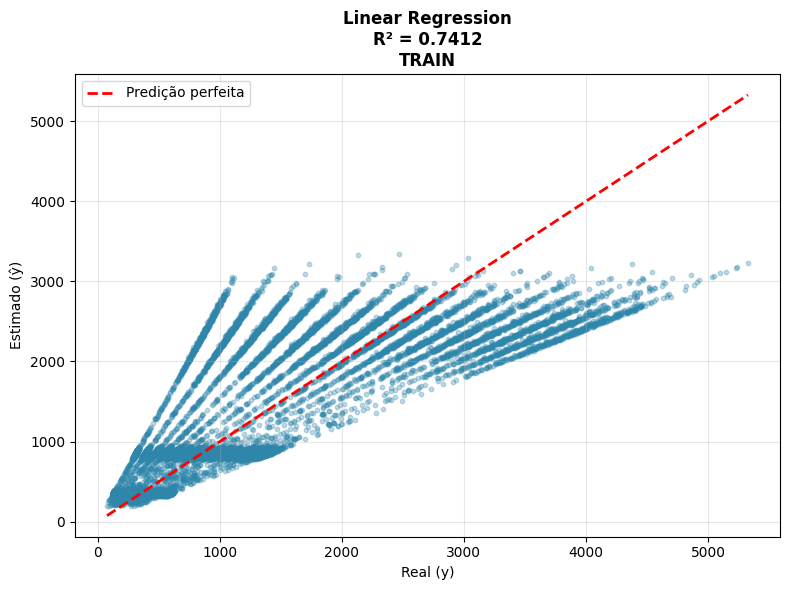

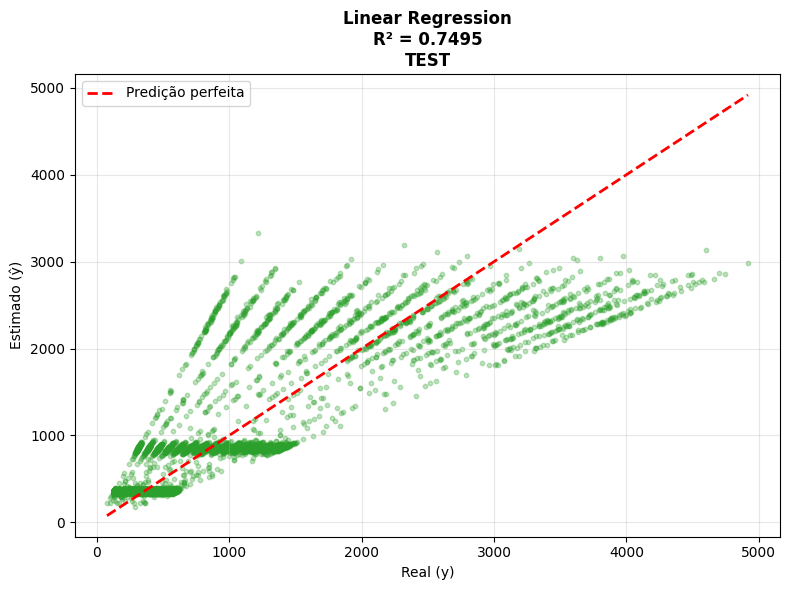

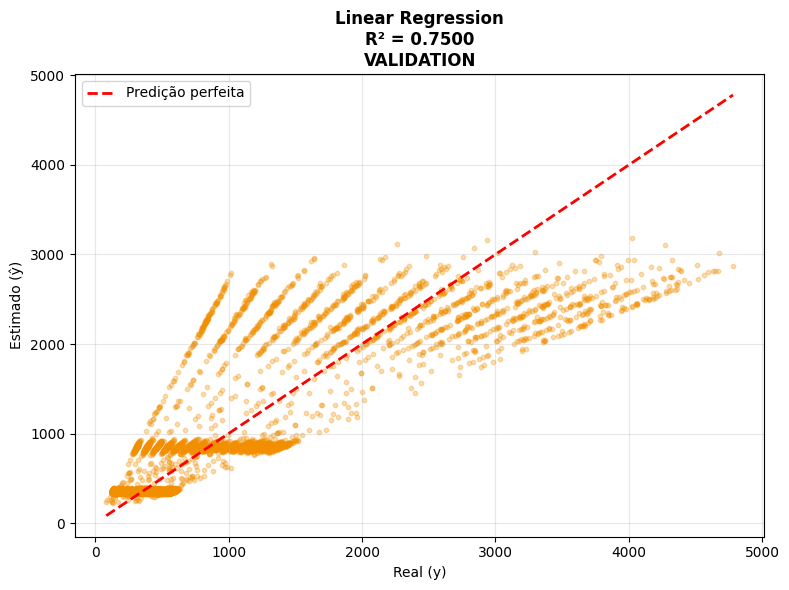

In [ ]:
## TRAIN
Atividade1_4_2(
    melhor_modelo_reg,
    melhor_resultado["Modelo"],
    X_train_array,
    y_train_array,
    "TRAIN"
)

## TEST

Atividade1_4_2(
    melhor_modelo_reg,
    melhor_resultado["Modelo"],
    X_test_array,
    y_test_array,
    "TEST"
)

## VALIDATION

Atividade1_4_2(
    melhor_modelo_reg,
    melhor_resultado["Modelo"],
    X_validation_array,
    y_validation_array,
    "VALIDATION"
)

### A1.4.3: Análise dos Resíduos: $\epsilon = y_{real} - y_{estimado}$

* Conjunto de Treinamento:

* Conjunto de Validação:

* Conjunto de Teste:

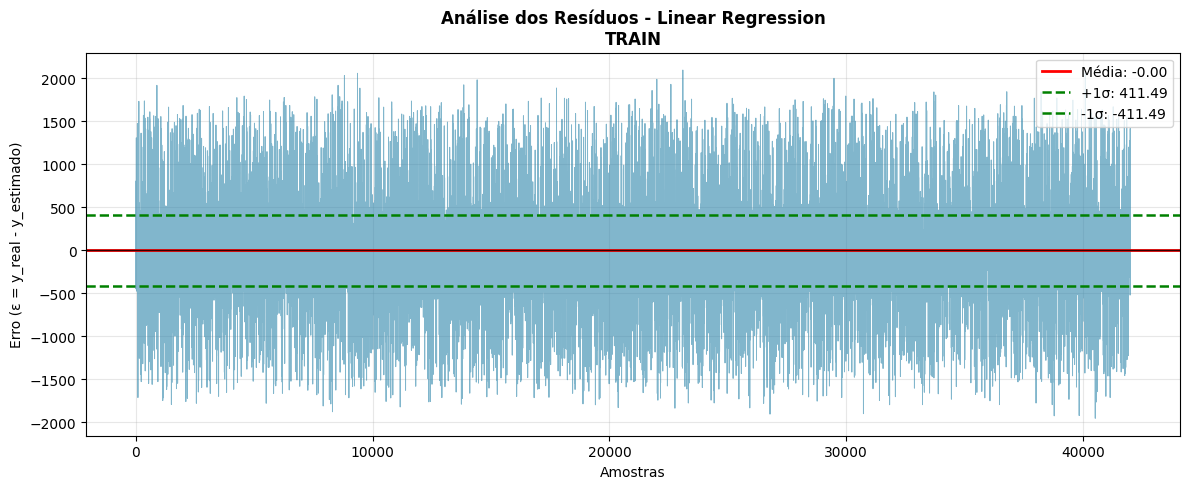


RESUMO DOS RESÍDUOS
----------------------------------------------------------------------
Modelo          : Linear Regression
Conjunto        : TRAIN
Média resíduos  : -0.0000
Desvio padrão   : 411.4860


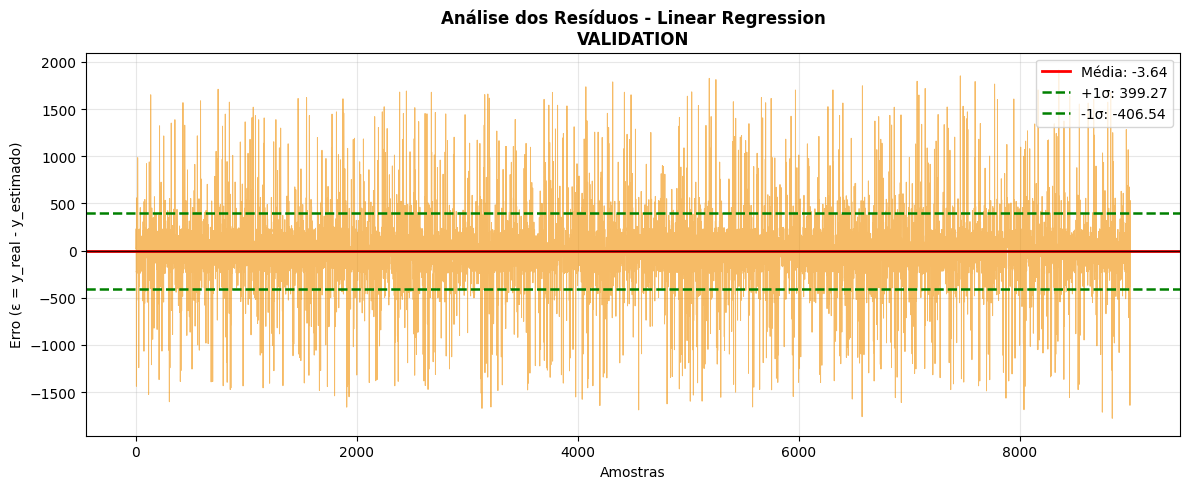


RESUMO DOS RESÍDUOS
----------------------------------------------------------------------
Modelo          : Linear Regression
Conjunto        : VALIDATION
Média resíduos  : -3.6358
Desvio padrão   : 402.9048


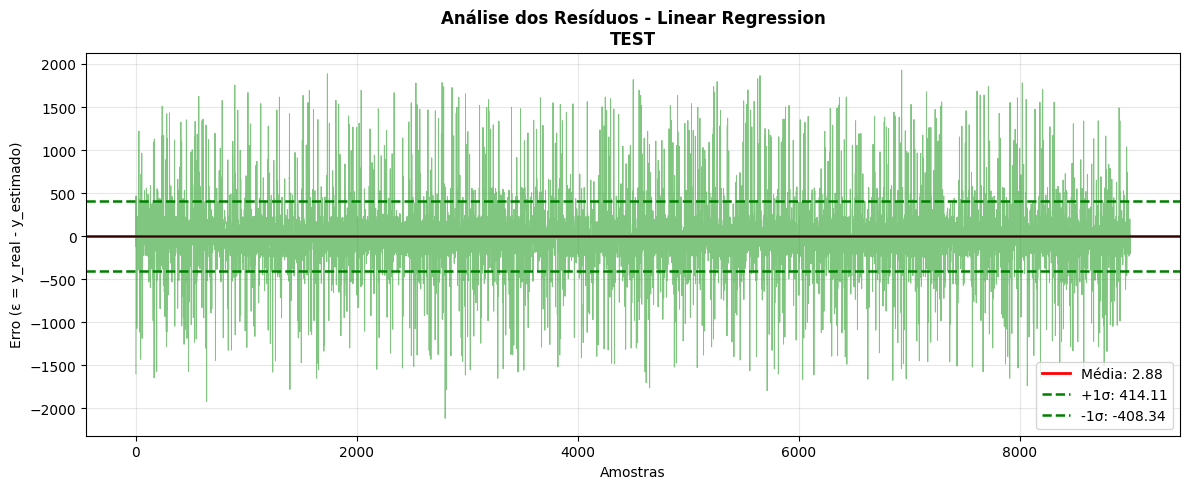


RESUMO DOS RESÍDUOS
----------------------------------------------------------------------
Modelo          : Linear Regression
Conjunto        : TEST
Média resíduos  : 2.8815
Desvio padrão   : 411.2238


In [ ]:
## TRAIN

Atividade1_4_3(
    melhor_modelo_reg,
    melhor_resultado["Modelo"],
    X_train_array,
    y_train_array,
    "TRAIN"
)

## VALIDATION

Atividade1_4_3(
    melhor_modelo_reg,
    melhor_resultado["Modelo"],
    X_validation_array,
    y_validation_array,
    "VALIDATION"
)

## TEST

Atividade1_4_3(
    melhor_modelo_reg,
    melhor_resultado["Modelo"],
    X_test_array,
    y_test_array,
    "TEST"
)

### A1.4.4: JOINT: Resíduos ($\epsilon$) vs Valores Estimado ($\hat{y}$)

* Conjunto de Treinamento: inspeção da estrutura residual (dispersão e possíveis padrões sistemáticos).

* Conjunto de Validação: foco principal para detectar heterocedasticidade e não linearidades residuais.

* Conjunto de Teste: confirmação final de comportamento residual consistente com validação.

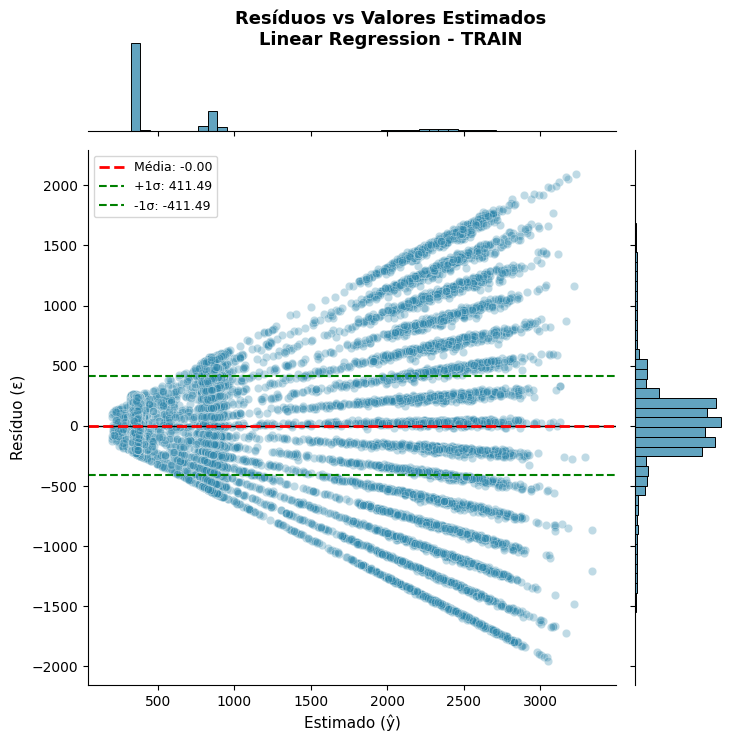


RESUMO DOS RESÍDUOS
----------------------------------------------------------------------
Modelo         : Linear Regression
Conjunto       : TRAIN
Média          : -0.0000
Desvio padrão  : 411.4860


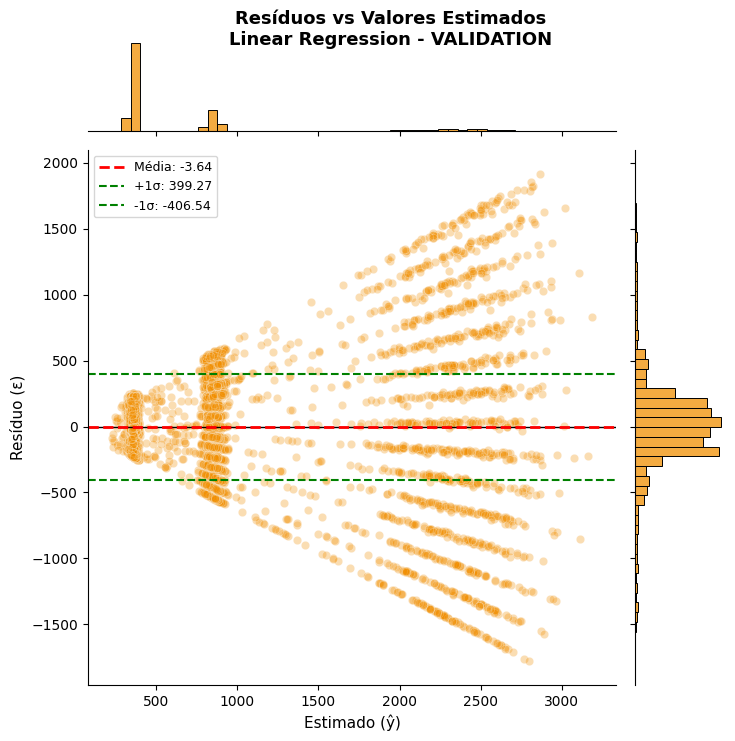


RESUMO DOS RESÍDUOS
----------------------------------------------------------------------
Modelo         : Linear Regression
Conjunto       : VALIDATION
Média          : -3.6358
Desvio padrão  : 402.9048


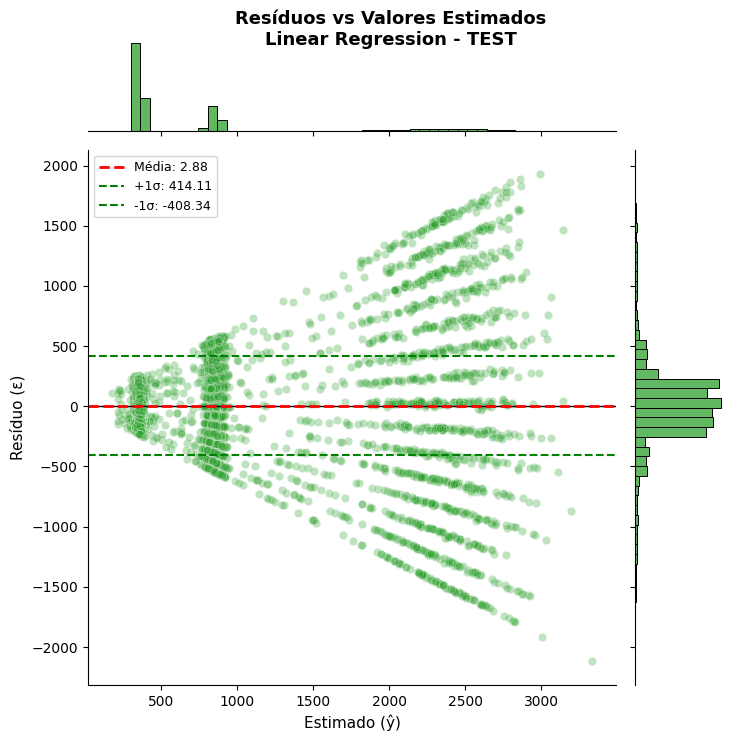


RESUMO DOS RESÍDUOS
----------------------------------------------------------------------
Modelo         : Linear Regression
Conjunto       : TEST
Média          : 2.8815
Desvio padrão  : 411.2238


In [ ]:
## TRAIN

Atividade1_4_4(
    melhor_modelo_reg,
    melhor_resultado["Modelo"],
    X_train_array,
    y_train_array,
    "TRAIN"
)

## VALIDATION

Atividade1_4_4(
    melhor_modelo_reg,
    melhor_resultado["Modelo"],
    X_validation_array,
    y_validation_array,
    "VALIDATION"
)

## TEST

Atividade1_4_4(
    melhor_modelo_reg,
    melhor_resultado["Modelo"],
    X_test_array,
    y_test_array,
    "TEST"
)

##Atividade A1.5 (5º Passo): Testar o Modelo: Dados da População: amostra aleatória (Sample).

Com base nos resultados dos modelos lineares e do complemento com regresssores não lineares, o modelo final de regressão passa a ser definido automaticamente pelo maior R2 no conjunto VALIDATION.

Essa abordagem reduz o risco de overfitting observado em modelos mais instáveis e melhora a consistência entre validação e teste para a etapa final do projeto.


SELECAO DO MODELO FINAL DE REGRESSAO
Top modelos por R2 no VALIDATION:
  1. Gradient Boosting                        R2 = 0.7511
  2. Linear Regression                        R2 = 0.7500
  3. Hist Gradient Boosting Regressor         R2 = 0.7497
  4. AdaBoost                                 R2 = 0.7480
  5. Extra Trees Regressor                    R2 = 0.7472
Modelo final fixado: Linear Regression
R2 VALIDATION (modelo final): 0.7500


TESTE DO MODELO - AMOSTRA ALEATORIA DA POPULACAO

  Modelo:                  Linear Regression
  Population size (TRAIN): 41,999
  Sample size:             1,000
  Seed:                    42

SUMMARY - SAMPLE

  R2:          0.7558
  MSE:         164741.6626
  RMSE:        405.8838
  MAE:         252.7844

  Residuos:
    Media (e): -0.6971
    Std (e):   405.8832
    Min (e):   -1713.3588
    Max (e):   1754.8958


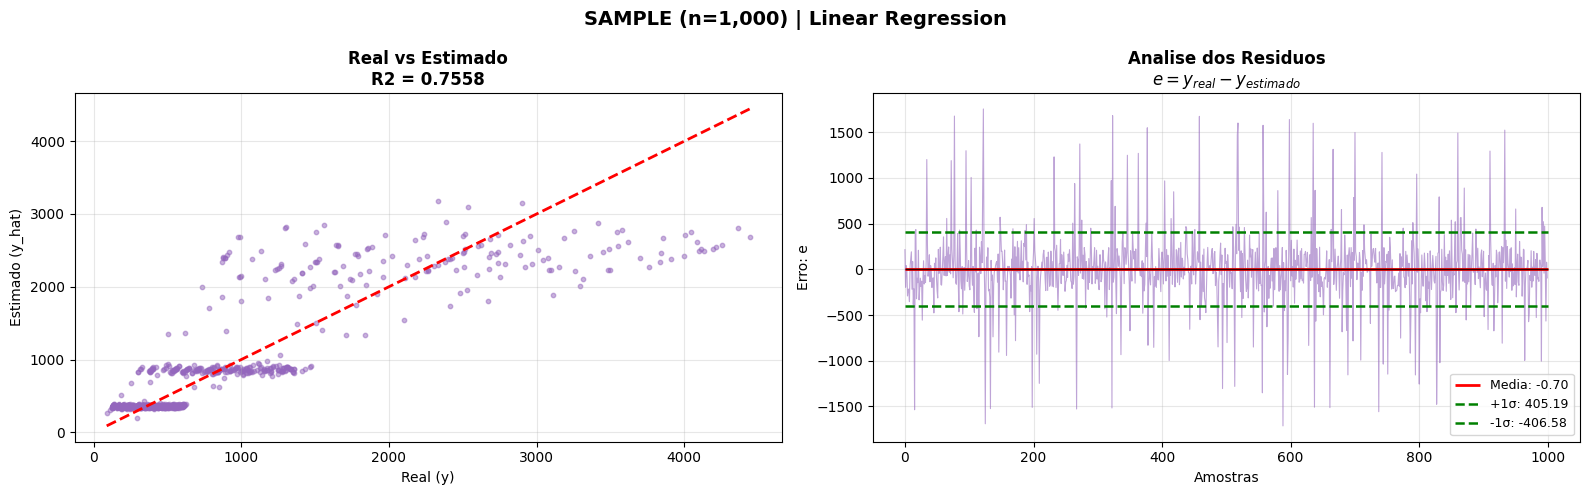


TESTE CONCLUIDO!



In [ ]:
# Consolidar candidatos
modelos_disponiveis = dict(modelos_treinados)
if 'regressors_avancados' in globals():
    modelos_disponiveis.update(regressors_avancados)

# Variavel para definir o modelo (ou None para automatico)
modelo_final_manual = 'Linear Regression'

# Ranking automatico em VALIDATION
ranking_modelos = []
for nome, modelo in modelos_disponiveis.items():
    r2_val = modelo.score(X_validation_array, y_validation_array)
    ranking_modelos.append((nome, r2_val))

ranking_modelos = sorted(ranking_modelos, key=lambda x: x[1], reverse=True)

print("\n" + "=" * 100)
print("SELECAO DO MODELO FINAL DE REGRESSAO")
print("=" * 100)
print("Top modelos por R2 no VALIDATION:")
for i, (nome, r2) in enumerate(ranking_modelos[:5], 1):
    print(f"  {i}. {nome:<40} R2 = {r2:.4f}")

# Logica robusta: sem excecao quando nao define modelo manual
if isinstance(modelo_final_manual, str):
    modelo_final_manual = modelo_final_manual.strip()

if modelo_final_manual:
    if modelo_final_manual in modelos_disponiveis:
        melhor_modelo_nome = modelo_final_manual
        melhor_modelo = modelos_disponiveis[melhor_modelo_nome]
        print(f"Modelo final fixado: {melhor_modelo_nome}")
    else:
        melhor_modelo_nome = ranking_modelos[0][0]
        melhor_modelo = modelos_disponiveis[melhor_modelo_nome]
        print("\nModo de selecao: AUTOMATICO (fallback)")
        print(f"Modelo manual '{modelo_final_manual}' nao encontrado.")
        print(f"Modelo final selecionado (maior R2 VALIDATION): {melhor_modelo_nome}")
else:
    melhor_modelo_nome = ranking_modelos[0][0]
    melhor_modelo = modelos_disponiveis[melhor_modelo_nome]
    print(f"Modelo final selecionado (maior R2 VALIDATION): {melhor_modelo_nome}")

print(f"R2 VALIDATION (modelo final): {melhor_modelo.score(X_validation_array, y_validation_array):.4f}")
print("=" * 100 + "\n")

# Testar com amostra aleatoria da populacao
resultado_sample = Atividade1_5(
    melhor_modelo,
    X_train_array,
    y_train_array,
    sample_size=1000,
    nome_modelo=melhor_modelo_nome
)

## RELATÓRIO PARCIAL - MODELO DE REGRESSÃO

Fazer aqui o **RELATÓRIO PARCIAL - MODELO DE REGRESSÃO** com todas as conclusões e resultados que serão apresentados aos gestores da **EMPRESA:**.

* Foram avaliados modelos lineares e não lineares (Gradient Boosting, Hist Gradient Boosting, AdaBoost e Extra Trees). Apesar de o Gradient Boosting ter apresentado o maior R² no conjunto de validação (0,7511), a diferença para a Regressão Linear (0,7500) foi insignificante. Por sua simplicidade, interpretabilidade e desempenho equivalente, a **Regressão Linear foi selecionada como modelo final**.
* A avaliação do modelo final em uma amostra aleatória de 1.000 registros da
população de treinamento resultou em **R² = 0,7558**, indicando que aproximadamente 75,6% da variabilidade da variável alvo é explicada pelo modelo. Além disso, os erros observados (RMSE = 405,88 e MAE = 252,78) permaneceram consistentes com os resultados obtidos durante as etapas de validação.
* A análise dos resíduos mostrou **média próxima de zero (-0,70)**, sugerindo ausência de viés sistemático nas previsões. Em conjunto com a estabilidade do R² entre validação e amostra aleatória, os resultados indicam que o modelo apresenta boa capacidade de generalização e não há evidências relevantes de overfitting.

#Atividade A2: Modelo de Clusterização

##Atividade A2.1 (1º Passo): Normalizar - Mapear - Discretizar

In [ ]:
resultado_prep_clustering = Atividade2_1(train, validation, test)

train_cluster = resultado_prep_clustering['train']
validation_cluster = resultado_prep_clustering['validation']
test_cluster = resultado_prep_clustering['test']


ATIVIDADE A2.1 - PREPARAÇÃO PARA CLUSTERIZAÇÃO
TRAIN original: (41999, 24) | TRAIN preparado: (41999, 9)
Numéricas usadas: ['DEPENDENTES', 'RENDA BRUTO (R$)', 'TOTAL (R$)', 'NOTA DE SATISFAÇÃO (%)']
Categóricas usadas: ['REGIÃO', 'SEXO', 'ESTADO CIVIL', 'TIPO DA CONTA', 'OPINIÃO DISCRETIZADA']
VALIDATION original: (9000, 24) | VALIDATION preparado: (9000, 9)
TEST original: (9000, 24) | TEST preparado: (9000, 9)



##Atividade A2.2 (2º Passo) - ETL: Separar Entrada ($X$) da Saída ($y$)

In [ ]:
# Separar X e y com sua função existente
x_train, y_train = Atividade2_2(train_cluster)
x_validation, y_validation = Atividade2_2(validation_cluster)
x_test, y_test = Atividade2_2(test_cluster)

##Atividade A2.3 (3º Passo): Aplicar o Método do Cotovelo

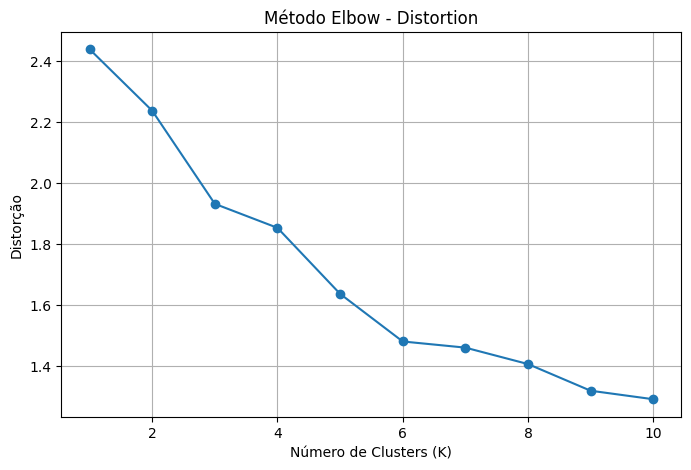

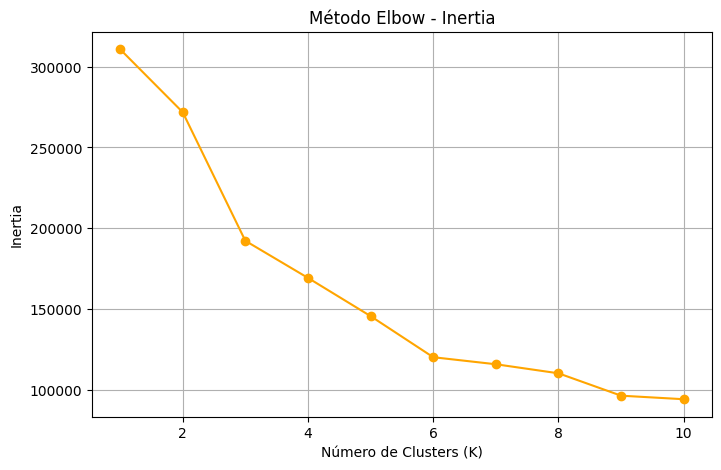

Valores de Distorção:
K=1: 2.4391
K=2: 2.2371
K=3: 1.9313
K=4: 1.8526
K=5: 1.6358
K=6: 1.4794
K=7: 1.4593
K=8: 1.4053
K=9: 1.3177
K=10: 1.2898

Valores de Inertia:
K=1: 310822.2151
K=2: 271800.2337
K=3: 192153.1812
K=4: 169181.2220
K=5: 145503.5957
K=6: 120046.7266
K=7: 115688.5713
K=8: 110082.9451
K=9: 96221.8522
K=10: 94027.1457


In [ ]:
mapping1_train, mapping2_train, distortions_train, inertias_train = Atividade2_3(x_train)

##Atividade A2.4 (4º Passo): Aplicar o Método da Silhueta

K=2 | Silhouette Score Médio = 0.1749


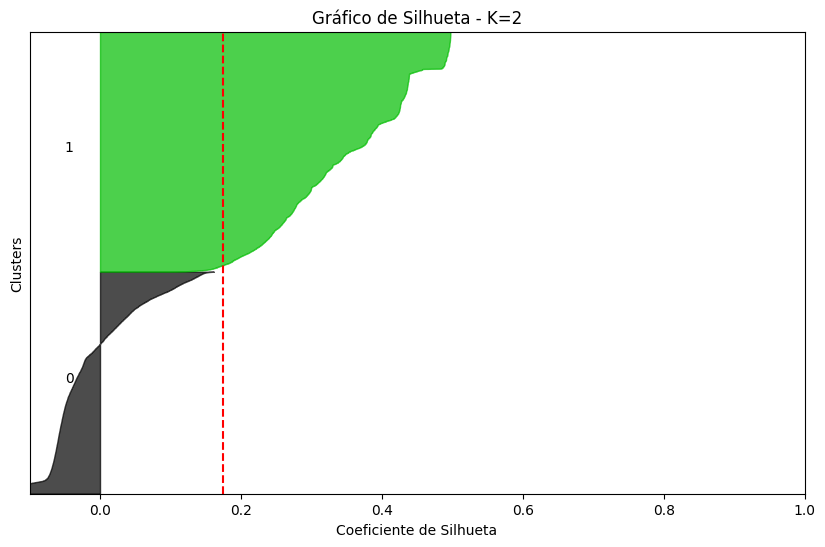

K=3 | Silhouette Score Médio = 0.3215


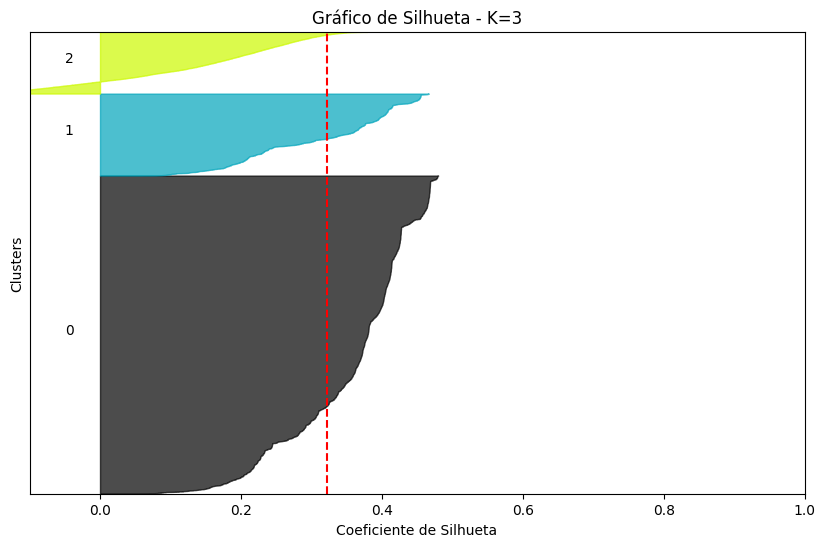

K=4 | Silhouette Score Médio = 0.3330


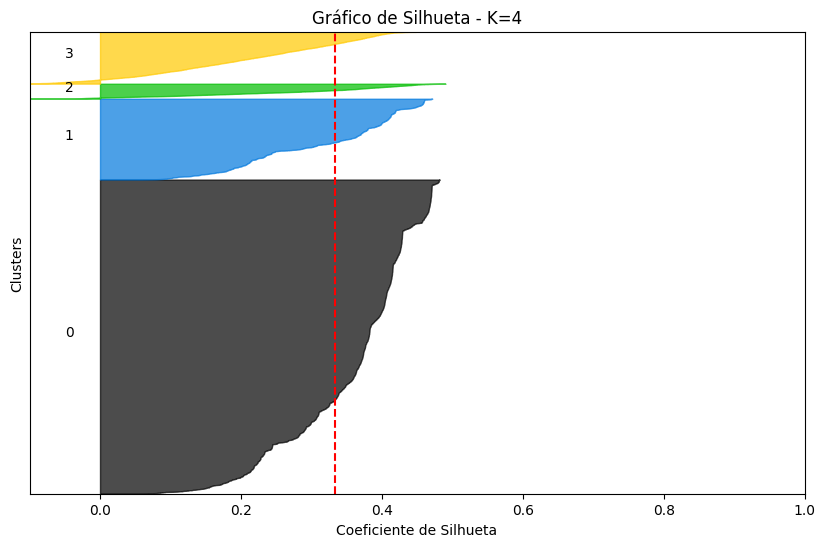

K=5 | Silhouette Score Médio = 0.2736


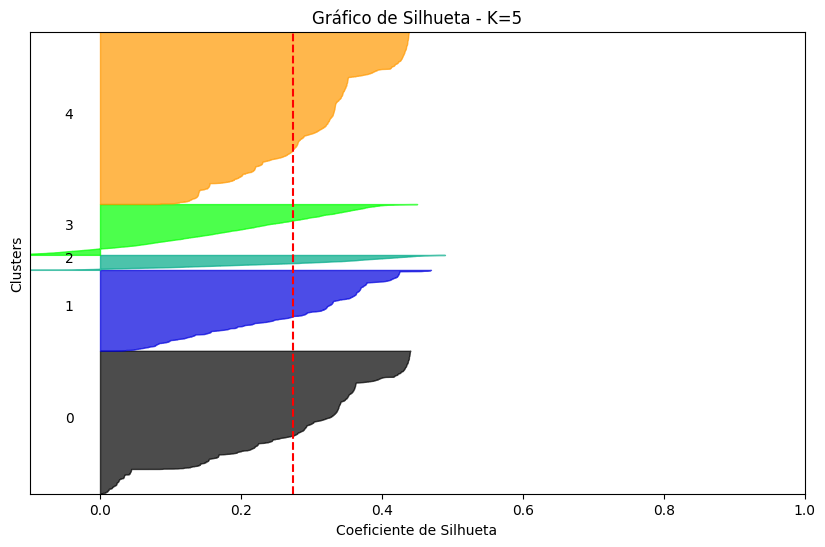

K=6 | Silhouette Score Médio = 0.3101


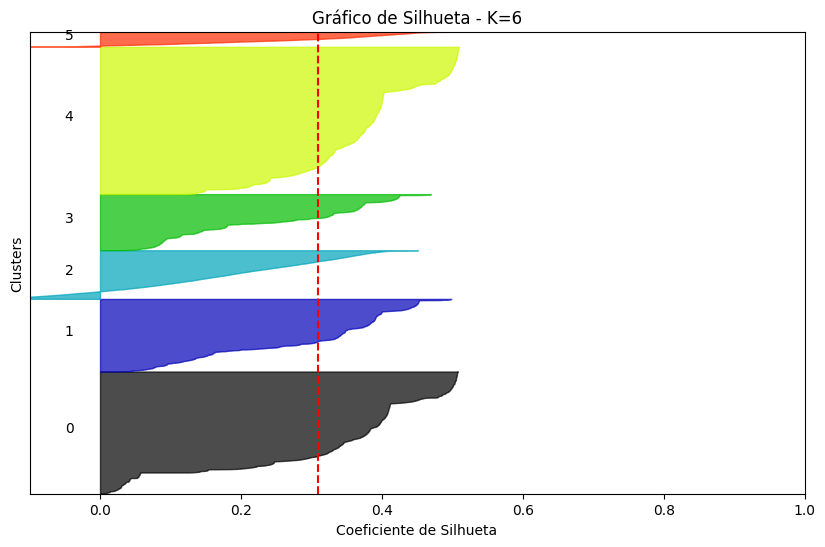

K=7 | Silhouette Score Médio = 0.3113


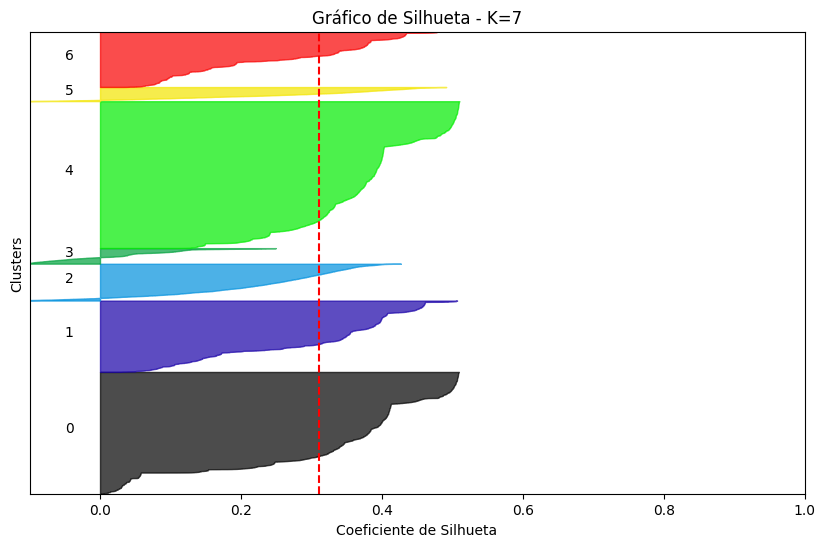

K=8 | Silhouette Score Médio = 0.3040


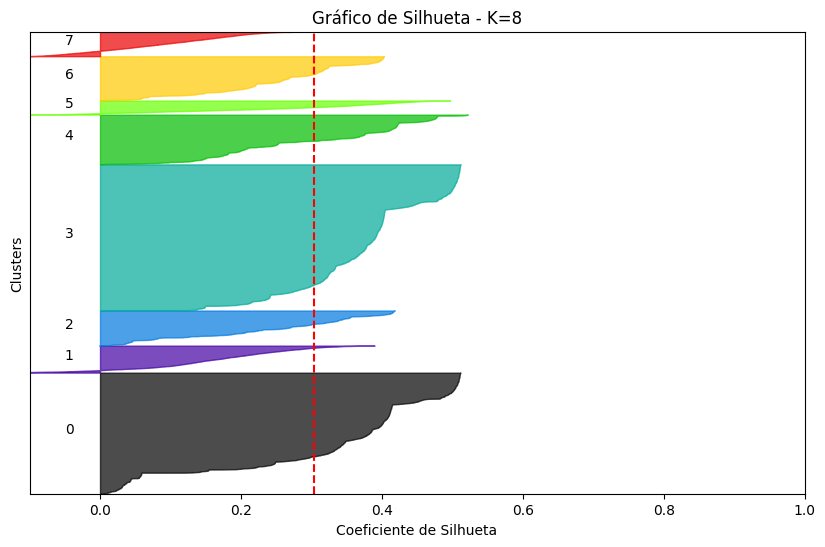

K=9 | Silhouette Score Médio = 0.3223


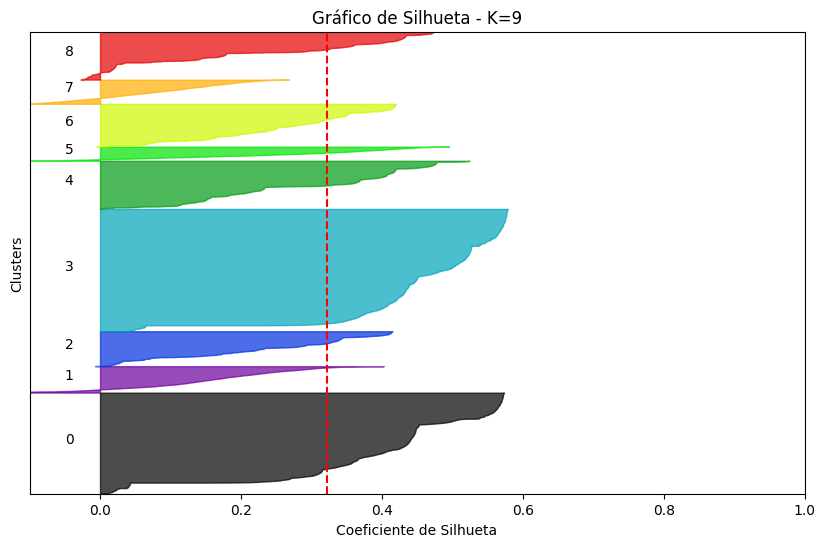

K=10 | Silhouette Score Médio = 0.2728


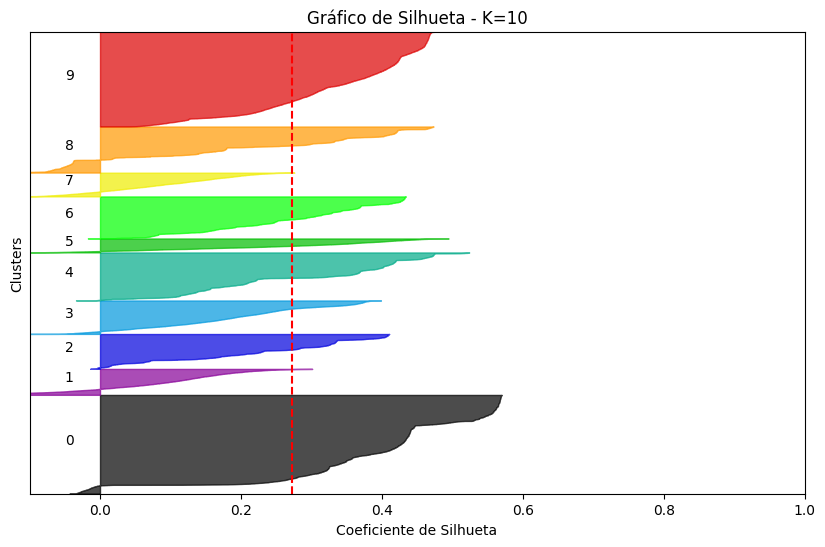

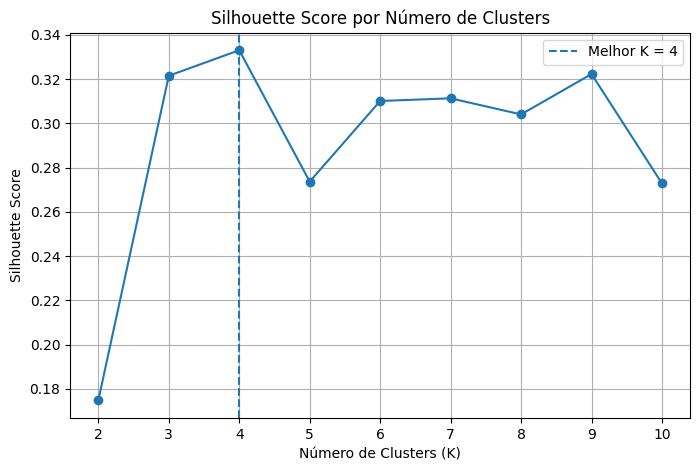


Resumo Final
K=2: 0.1749
K=3: 0.3215
K=4: 0.3330
K=5: 0.2736
K=6: 0.3101
K=7: 0.3113
K=8: 0.3040
K=9: 0.3223
K=10: 0.2728

Melhor K: 4
Melhor Silhouette Score: 0.3330


In [ ]:
silhouette_scores_train, melhor_k_train = Atividade2_4(
    x_train,
    min_k=2,
    max_k=10
)

##Atividade A2.5 (5º Passo): Criar o Modelo: **Clusters**

In [ ]:
x_train_array = x_train.values
y_train_array = y_train.values

x_validation_array = x_validation.values
y_validation_array = y_validation.values

x_test_array = x_test.values
y_test_array = y_test.values

train_cluster_array = train_cluster.values
validation_cluster_array = validation_cluster.values
test_cluster_array = test_cluster.values

print("x_train_array:", x_train_array.shape)
print("y_train_array:", y_train_array.shape)
print("x_validation_array:", x_validation_array.shape)
print("y_validation_array:", y_validation_array.shape)
print("x_test_array:", x_test_array.shape)
print("y_test_array:", y_test_array.shape)
print("train_cluster_array:", train_cluster_array.shape)
print("validation_cluster_array:", validation_cluster_array.shape)
print("test_cluster_array:", test_cluster_array.shape)

x_train_array: (41999, 8)
y_train_array: (41999,)
x_validation_array: (9000, 8)
y_validation_array: (9000,)
x_test_array: (9000, 8)
y_test_array: (9000,)
train_cluster_array: (41999, 9)
validation_cluster_array: (9000, 9)
test_cluster_array: (9000, 9)


In [ ]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(x_train_array)

KMeans(n_clusters=4, random_state=42)

In [ ]:
labels_train = kmeans.labels_
labels_validation = kmeans.predict(x_validation_array)
labels_test = kmeans.predict(x_test_array)

In [ ]:
counts_train = np.bincount(labels_train, minlength=k)
counts_validation = np.bincount(labels_validation, minlength=k)
counts_test = np.bincount(labels_test, minlength=k)

print("TRAIN counts:", counts_train)
print("VALIDATION counts:", counts_validation)
print("TEST counts:", counts_test)

TRAIN counts: [28580  7350  1356  4713]
VALIDATION counts: [6111 1581  290 1018]
TEST counts: [6172 1529  301  998]


In [ ]:
counts_train = np.bincount(labels_train, minlength=k)
counts_validation = np.bincount(labels_validation, minlength=k)
counts_test = np.bincount(labels_test, minlength=k)

print("TRAIN counts:", counts_train)
print("VALIDATION counts:", counts_validation)
print("TEST counts:", counts_test)

TRAIN counts: [28580  7350  1356  4713]
VALIDATION counts: [6111 1581  290 1018]
TEST counts: [6172 1529  301  998]


In [ ]:
pct_train = counts_train / counts_train.sum() * 100
pct_validation = counts_validation / counts_validation.sum() * 100
pct_test = counts_test / counts_test.sum() * 100

print("\nProporções TRAIN:")
for i, p in enumerate(pct_train):
    print(f"CLUSTER {i}: {p:.1f}% ({counts_train[i]})")


Proporções TRAIN:
CLUSTER 0: 68.0% (28580)
CLUSTER 1: 17.5% (7350)
CLUSTER 2: 3.2% (1356)
CLUSTER 3: 11.2% (4713)


In [ ]:
print("\nProporções VALIDATION:")
for i, p in enumerate(pct_validation):
    print(f"CLUSTER {i}: {p:.1f}% ({counts_validation[i]})")


Proporções VALIDATION:
CLUSTER 0: 67.9% (6111)
CLUSTER 1: 17.6% (1581)
CLUSTER 2: 3.2% (290)
CLUSTER 3: 11.3% (1018)


In [ ]:
print("\nProporções TEST:")
for i, p in enumerate(pct_test):
    print(f"CLUSTER {i}: {p:.1f}% ({counts_test[i]})")


Proporções TEST:
CLUSTER 0: 68.6% (6172)
CLUSTER 1: 17.0% (1529)
CLUSTER 2: 3.3% (301)
CLUSTER 3: 11.1% (998)


In [ ]:
k = 3 ## Fixado K3 decvido ao cluster 02 quando K=4 ter baixissima representatividade
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(x_train_array)

KMeans(n_clusters=3, random_state=42)

In [ ]:
labels_train = kmeans.labels_
labels_validation = kmeans.predict(x_validation_array)
labels_test = kmeans.predict(x_test_array)

In [ ]:
counts_train = np.bincount(labels_train, minlength=k)
counts_validation = np.bincount(labels_validation, minlength=k)
counts_test = np.bincount(labels_test, minlength=k)

print("TRAIN counts:", counts_train)
print("VALIDATION counts:", counts_validation)
print("TEST counts:", counts_test)

TRAIN counts: [28935  7450  5614]
VALIDATION counts: [6191 1603 1206]
TEST counts: [6248 1548 1204]


In [ ]:
pct_train = counts_train / counts_train.sum() * 100
pct_validation = counts_validation / counts_validation.sum() * 100
pct_test = counts_test / counts_test.sum() * 100

##Atividade A2.6 (6º Passo): Medir a acurácia (score) dos Modelos de Clusterização:

####Atividade A2.6.1: Medir a Proporção dos clusters: Conjunto TRAIN

In [ ]:
print("\nProporções TRAIN:")
for i, p in enumerate(pct_train):
    print(f"CLUSTER {i}: {p:.1f}% ({counts_train[i]})")



Proporções TRAIN:
CLUSTER 0: 68.9% (28935)
CLUSTER 1: 17.7% (7450)
CLUSTER 2: 13.4% (5614)


####Atividade A2.6.2: Medir a Proporção dos clusters: Conjunto VALIDATION

In [ ]:
print("\nProporções VALIDATION:")
for i, p in enumerate(pct_validation):
    print(f"CLUSTER {i}: {p:.1f}% ({counts_validation[i]})")



Proporções VALIDATION:
CLUSTER 0: 68.8% (6191)
CLUSTER 1: 17.8% (1603)
CLUSTER 2: 13.4% (1206)


####Atividade A2.6.3: Medir a Proporção dos clusters: Conjunto TEST

In [ ]:
print("\nProporções TEST:")
for i, p in enumerate(pct_test):
    print(f"CLUSTER {i}: {p:.1f}% ({counts_test[i]})")


Proporções TEST:
CLUSTER 0: 69.4% (6248)
CLUSTER 1: 17.2% (1548)
CLUSTER 2: 13.4% (1204)


##Atividade A2.7 (7º Passo): Testar o Modelo: Dados da População: amostra aleatória (Sample).

In [ ]:
sample_size = 1000
seed = 42
np.random.seed(seed)

# Amostra aleatória sem reposição da população (TRAIN)
idx_sample = np.random.choice(len(x_train_array), size=sample_size, replace=False)
X_sample = x_train_array[idx_sample]

# Predição dos clusters na amostra
labels_pop = kmeans.labels_
labels_sample = kmeans.predict(X_sample)

k = kmeans.n_clusters

# Proporções população vs amostra
counts_pop = np.bincount(labels_pop, minlength=k)
counts_sample = np.bincount(labels_sample, minlength=k)

pct_pop = counts_pop / counts_pop.sum() * 100
pct_sample = counts_sample / counts_sample.sum() * 100

# Qualidade da amostra (silhouette)
sil_sample = silhouette_score(X_sample, labels_sample)

print("\n" + "=" * 100)
print("TESTE DO MODELO COM AMOSTRA ALEATÓRIA (SAMPLE)")
print("=" * 100)
print(f"Tamanho da população (TRAIN): {len(x_train_array):,}")
print(f"Tamanho da amostra:           {sample_size:,}")
print(f"Silhouette da amostra:        {sil_sample:.4f}")
print("-" * 100)

for c in range(k):
    diff = pct_sample[c] - pct_pop[c]
    print(
        f"CLUSTER {c}: "
        f"População = {pct_pop[c]:5.1f}% ({counts_pop[c]:5d}) | "
        f"Amostra = {pct_sample[c]:5.1f}% ({counts_sample[c]:4d}) | "
        f"Δ = {diff:+.2f} p.p."
    )

print("=" * 100 + "\n")


TESTE DO MODELO COM AMOSTRA ALEATÓRIA (SAMPLE)
Tamanho da população (TRAIN): 41,999
Tamanho da amostra:           1,000
Silhouette da amostra:        0.3257
----------------------------------------------------------------------------------------------------
CLUSTER 0: População =  68.9% (28935) | Amostra =  68.4% ( 684) | Δ = -0.49 p.p.
CLUSTER 1: População =  17.7% ( 7450) | Amostra =  16.7% ( 167) | Δ = -1.04 p.p.
CLUSTER 2: População =  13.4% ( 5614) | Amostra =  14.9% ( 149) | Δ = +1.53 p.p.



## RELATÓRIO PARCIAL - MODELO DE CLUSTERIZAÇÃO

Fazer aqui o **RELATÓRIO PARCIAL - MODELO DE CLUSTERIZAÇÃO** com todas as conclusões e resultados que serão apresentados aos gestores da **EMPRESA:**.

* O teste com amostra (n=1.000) validou o modelo de clusterização
com K=3: a amostra preservou a distribuição da população, sem evidência de distorção relevante.

* O K=4 foi avaliado, mas descartado porque um dos clusters ficou muito pequeno (quase residual), sem valor estratégico claro.

* A robustez do K-Means (K=3) foi confirmada por alta aderência entre amostra e treino (desvios < 1,6 p.p.) e silhouette de 0,3257, indicando estabilidade da segmentação.

#Atividade A3: Modelo de Classificação

##Atividade A3.1 (1º Passo): Normalizar - Mapear - Discretizar

In [ ]:
resultado_prep_class = Atividade3_1(train, validation, test)

train_class = resultado_prep_class['train']
validation_class = resultado_prep_class['validation']
test_class = resultado_prep_class['test']

print(train_class.shape)
print(validation_class.shape)
print(test_class.shape)


NORMALIZAR | MAPEAR | DISCRETIZAR (CLASSIFICAÇÃO)
Target (y): TIPO DA CONTA
Numéricas: ['DEPENDENTES', 'RENDA BRUTO (R$)', 'TOTAL (R$)', 'NOTA DE SATISFAÇÃO (%)']
Categóricas X: ['REGIÃO', 'SEXO', 'ESTADO CIVIL', 'OPINIÃO DISCRETIZADA']
VALIDATION: (9000, 24) -> (9000, 9)
TEST: (9000, 24) -> (9000, 9)

(41999, 9)
(9000, 9)
(9000, 9)


##Atividade A3.2 (2º Passo) - ETL: Separar Entrada ($X$) da Saída ($y$)

In [ ]:
# Coluna alvo
coluna_alvo = 'TIPO DA CONTA'

# TRAIN
X_train_array = train_class.drop(columns=[coluna_alvo]).values
y_train_array = train_class[coluna_alvo].values

# VALIDATION
X_validation_array = validation_class.drop(columns=[coluna_alvo]).values
y_validation_array = validation_class[coluna_alvo].values

# TEST
X_test_array = test_class.drop(columns=[coluna_alvo]).values
y_test_array = test_class[coluna_alvo].values

# Resumo
print("=" * 100)
print(f"X_train_array:      {X_train_array.shape} | y_train_array:      {y_train_array.shape}")
print(f"X_validation_array: {X_validation_array.shape} | y_validation_array: {y_validation_array.shape}")
print(f"X_test_array:       {X_test_array.shape} | y_test_array:       {y_test_array.shape}")
print("=" * 100 + "\n")

X_train_array:      (41999, 8) | y_train_array:      (41999,)
X_validation_array: (9000, 8) | y_validation_array: (9000,)
X_test_array:       (9000, 8) | y_test_array:       (9000,)



##Atividade A3.3 (3º Passo): Escolher / Criar o Modelo: **Classifiers**

In [ ]:
classifiers = {
    "Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Linear SVM": LinearSVC(random_state=42, max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(),

}


Escolher enter os seguintes - **Classifiers**:

1.   Nearest Neighbors
2.   Linear SVM
2.   RBF SVM
2.   Gaussian Process
2.   Decision Tree
2.   Random Forest
2.   Neural Net
2.   AdaBoost
2.   Naive Bayes
2.   QDA

**Qual obteve o maior SCORE ?**

In [ ]:
modelos_treinados_cls = {}

if isinstance(classifiers, list):
    classifiers = {f"Modelo_{i+1}": modelo for i, modelo in enumerate(classifiers)}

if not hasattr(classifiers, 'items'):
    raise TypeError("A variável 'classifiers' deve ser um dicionário de modelos.")

for nome_modelo, modelo in classifiers.items():
    print(f"Treinando modelo: {nome_modelo}")

    modelo.fit(X_train_array, y_train_array)
    modelos_treinados_cls[nome_modelo] = modelo

    print(f"Status: {nome_modelo} treinado com sucesso (base completa).\n")

print("-" * 70)
print("Todos os modelos de Classificação foram criados e treinados com sucesso.")
print(f"Total de modelos treinados: {len(modelos_treinados_cls)}")

Treinando modelo: Nearest Neighbors
Status: Nearest Neighbors treinado com sucesso (base completa).

Treinando modelo: Linear SVM
Status: Linear SVM treinado com sucesso (base completa).

Treinando modelo: Decision Tree
Status: Decision Tree treinado com sucesso (base completa).

Treinando modelo: Random Forest
Status: Random Forest treinado com sucesso (base completa).

Treinando modelo: AdaBoost
Status: AdaBoost treinado com sucesso (base completa).

Treinando modelo: Naive Bayes
Status: Naive Bayes treinado com sucesso (base completa).

Treinando modelo: QDA
Status: QDA treinado com sucesso (base completa).

----------------------------------------------------------------------
Todos os modelos de Classificação foram criados e treinados com sucesso.
Total de modelos treinados: 7


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


### A3.3.1: Intervalo de confiança: Train

In [ ]:
def intervalo_confianca_acuracia(y_true, y_pred, z=1.96):
    n = len(y_true)
    p = np.mean(y_true == y_pred)
    erro = z * np.sqrt((p * (1 - p)) / n)
    li = max(0.0, p - erro)
    ls = min(1.0, p + erro)
    return p, li, ls

resultados_train_cls = []

for nome_modelo, modelo in modelos_treinados_cls.items():
    pred_train = modelo.predict(X_train_array)
    acc, li, ls = intervalo_confianca_acuracia(y_train_array, pred_train)

    resultados_train_cls.append({
        'Modelo': nome_modelo,
        'Acurácia_Train': acc,
        'IC95%_LI': li,
        'IC95%_LS': ls
    })

df_resultados_train_cls = pd.DataFrame(resultados_train_cls).sort_values(
    by='Acurácia_Train',
    ascending=False
).reset_index(drop=True)

print('=' * 100)
print('ACURÁCIA E INTERVALO DE CONFIANÇA (TRAIN)')
print('=' * 100)
display(df_resultados_train_cls.style.format({
    'Acurácia_Train': '{:.4f}',
    'IC95%_LI': '{:.4f}',
    'IC95%_LS': '{:.4f}'
}))
print('=' * 100 + '\n')

ACURÁCIA E INTERVALO DE CONFIANÇA (TRAIN)


,Modelo,Acurácia_Train,IC95%_LI,IC95%_LS
0,Decision Tree,1.0000,1.0000,1.0000
1,Random Forest,1.0000,1.0000,1.0000
2,Nearest Neighbors,0.9732,0.9717,0.9748
3,AdaBoost,0.9719,0.9703,0.9735
4,Naive Bayes,0.9716,0.9700,0.9732
5,Linear SVM,0.9711,0.9695,0.9727
6,QDA,0.9373,0.9350,0.9396


### A3.3.2: Intervalo de confiança: Validation

In [ ]:
resultados_validation_cls = []

for nome_modelo, modelo in modelos_treinados_cls.items():
    pred_validation = modelo.predict(X_validation_array)
    acc, li, ls = intervalo_confianca_acuracia(y_validation_array, pred_validation)

    resultados_validation_cls.append({
        'Modelo': nome_modelo,
        'Acurácia_Validation': acc,
        'IC95%_LI': li,
        'IC95%_LS': ls
    })

df_resultados_validation_cls = pd.DataFrame(resultados_validation_cls).sort_values(
    by='Acurácia_Validation',
    ascending=False
).reset_index(drop=True)

melhor_modelo_nome = df_resultados_validation_cls.loc[0, 'Modelo']
melhor_modelo_cls = modelos_treinados_cls[melhor_modelo_nome]

print('=' * 100)
print('ACURÁCIA E INTERVALO DE CONFIANÇA (VALIDATION)')
print('=' * 100)
display(df_resultados_validation_cls.style.format({
    'Acurácia_Validation': '{:.4f}',
    'IC95%_LI': '{:.4f}',
    'IC95%_LS': '{:.4f}'
}))
print(f"Melhor modelo na VALIDATION: {melhor_modelo_nome}")
print('=' * 100 + '\n')

ACURÁCIA E INTERVALO DE CONFIANÇA (VALIDATION)


,Modelo,Acurácia_Validation,IC95%_LI,IC95%_LS
0,AdaBoost,0.9728,0.9694,0.9761
1,Naive Bayes,0.9720,0.9686,0.9754
2,Linear SVM,0.9718,0.9684,0.9752
3,Random Forest,0.9717,0.9682,0.9751
4,Nearest Neighbors,0.9664,0.9627,0.9702
5,Decision Tree,0.9658,0.9620,0.9695
6,QDA,0.9389,0.9339,0.9438


Melhor modelo na VALIDATION: AdaBoost



##Atividade A3.4 (4º Passo): Medir a acurácia (score) dos Modelos de Classificação:

####Atividade A3.4.1: Medir a acurácia (score) - Matriz de Confusão: Conjunto TRAIN

MATRIZ DE CONFUSÃO (TRAIN)


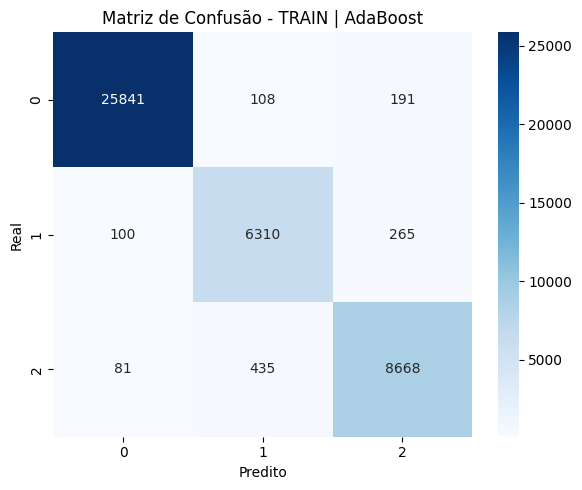

Acurácia TRAIN (AdaBoost): 0.9719



In [ ]:
print('=' * 100)
print('MATRIZ DE CONFUSÃO (TRAIN)')
print('=' * 100)

pred_train_best = melhor_modelo_cls.predict(X_train_array)
acc_train_best = np.mean(pred_train_best == y_train_array)

cm_train = confusion_matrix(y_train_array, pred_train_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusão - TRAIN | {melhor_modelo_nome}')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(f"Acurácia TRAIN ({melhor_modelo_nome}): {acc_train_best:.4f}")
print('=' * 100 + '\n')

####Atividade A3.4.2: Medir a acurácia (score) - Matriz de Confusão: Conjunto VALIDATION

A3.4.2 - MATRIZ DE CONFUSÃO (VALIDATION)


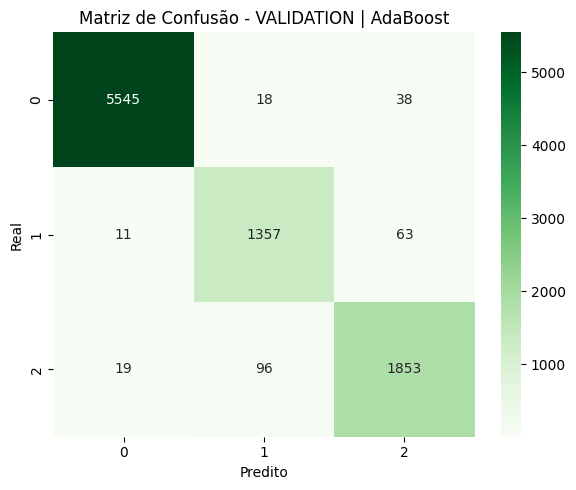

Acurácia VALIDATION (AdaBoost): 0.9728



In [ ]:
print('=' * 100)
print('A3.4.2 - MATRIZ DE CONFUSÃO (VALIDATION)')
print('=' * 100)

pred_validation_best = melhor_modelo_cls.predict(X_validation_array)
acc_validation_best = np.mean(pred_validation_best == y_validation_array)

cm_validation = confusion_matrix(y_validation_array, pred_validation_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_validation, annot=True, fmt='d', cmap='Greens')
plt.title(f'Matriz de Confusão - VALIDATION | {melhor_modelo_nome}')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(f"Acurácia VALIDATION ({melhor_modelo_nome}): {acc_validation_best:.4f}")
print('=' * 100 + '\n')

####Atividade A3.4.3: Medir a acurácia (score) - Matriz de Confusão: Conjunto TEST

A3.4.3 - MATRIZ DE CONFUSÃO (TEST)


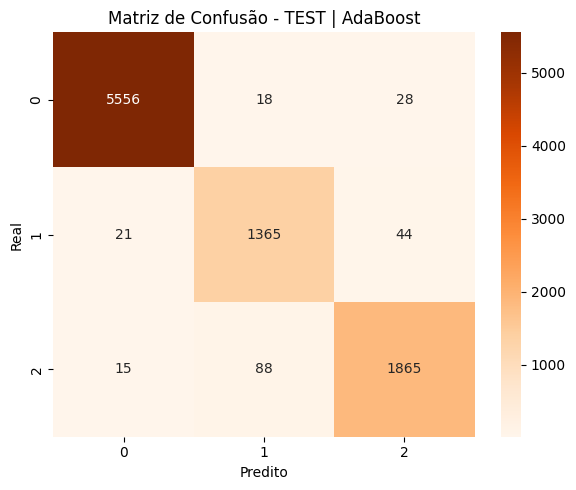

Acurácia TEST (AdaBoost): 0.9762



In [ ]:
print('=' * 100)
print('A3.4.3 - MATRIZ DE CONFUSÃO (TEST)')
print('=' * 100)

pred_test_best = melhor_modelo_cls.predict(X_test_array)
acc_test_best = np.mean(pred_test_best == y_test_array)

cm_test = confusion_matrix(y_test_array, pred_test_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Matriz de Confusão - TEST | {melhor_modelo_nome}')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(f"Acurácia TEST ({melhor_modelo_nome}): {acc_test_best:.4f}")
print('=' * 100 + '\n')

##Atividade A3.5 (5º Passo): Testar o Modelo: Dados da População: amostra aleatória (Sample).

In [ ]:
sample_size_pop = 1000
rng_pop = np.random.default_rng(42)
idx_pop = rng_pop.choice(len(X_train_array), size=min(sample_size_pop, len(X_train_array)), replace=False)

X_sample_pop = X_train_array[idx_pop]
y_sample_pop = y_train_array[idx_pop]

pred_sample_pop = melhor_modelo_cls.predict(X_sample_pop)
acc_sample_pop = np.mean(pred_sample_pop == y_sample_pop)

dist_real = pd.Series(y_sample_pop).value_counts(normalize=True).sort_index()
dist_pred = pd.Series(pred_sample_pop).value_counts(normalize=True).sort_index()

df_dist = pd.DataFrame({
    'Distribuição_Real': dist_real,
    'Distribuição_Predita': dist_pred
}).fillna(0)

print('=' * 100)
print('TESTE DO MODELO EM AMOSTRA DA POPULAÇÃO (SAMPLE)')
print('=' * 100)
print(f"Melhor modelo (validation): {melhor_modelo_nome}")
print(f"Tamanho da amostra: {len(X_sample_pop):,}")
print(f"Acurácia na amostra: {acc_sample_pop:.4f}")
display(df_dist.style.format('{:.2%}'))
print('=' * 100 + '\n')

TESTE DO MODELO EM AMOSTRA DA POPULAÇÃO (SAMPLE)
Melhor modelo (validation): AdaBoost
Tamanho da amostra: 1,000
Acurácia na amostra: 0.9780


,Distribuição_Real,Distribuição_Predita
0,61.80%,61.50%
1,16.00%,16.40%
2,22.20%,22.10%


## RELATÓRIO PARCIAL - MODELO DE CLASSIFICAÇÃO

Fazer aqui o **RELATÓRIO PARCIAL - MODELO DE CLASSIFICAÇÃO** com todas as conclusões e resultados que serão apresentados aos gestores da **EMPRESA:**.

* O modelo escolhido foi a AdaBoost, com melhor desempenho em validação (acurácia 0.9728), mantendo alta capacidade de generalização em relação ao treino (0.9719).

* No teste com amostra da população (n=1.000), o modelo manteve acurácia elevada (0.9780) e distribuições preditas muito próximas das reais, reforçando a robustez da classificação.

* Observação: nem todos os modelos de classificação sugeridos foram executados, pois alguns apresentaram custo computacional elevado para o ambiente disponível, o que inviabilizou rodar todos.

Modelos não executados:

* RBF SVM
* Gaussian Process
* Neural Net

# RELATÓRIO FINAL - VISÃO HOLÍSTICA SOBRE O PROJETO

Fazer aqui o **RELATÓRIO FINAL** com todas as conclusões e resultados que serão apresentados aos gestores da **EMPRESA:**.

Os resultados mostram um cenário bastante sólido para apoiar decisões de negócio em três frentes. Na previsão de valor, o modelo final de Regressão Linear apresentou desempenho estável entre as etapas de avaliação (R² de 0,7412 no treino, 0,7500 na validação e 0,7495 no teste), o que indica boa capacidade de manter qualidade quando aplicado fora da base usada para construir o modelo. Em termos práticos, isso dá confiança para usar as previsões no planejamento comercial e financeiro, com menor risco de perda de precisão ao entrar em operação.

Na segmentação de clientes, a escolha operacional foi o K-Means com K=3, com silhouette de referência em torno de 0,3257 e comportamento consistente entre treino, validação e teste na distribuição dos grupos, sustentando seu uso para estratégias de perfil, ofertas e relacionamento. Já na classificação do tipo de conta, o modelo final AdaBoost entregou desempenho elevado e consistente (acurácia de 0,9719 no treino, 0,9728 na validação, 0,9762 no teste e 0,9780 em amostra da população), reforçando que a solução funciona bem não só nos dados internos, mas também em cenários mais próximos da realidade do negócio.